In [1]:
# =============================================================================
# PAPYRUS FEATURE EXTRACTION (NO CLASSIFICATION)
# =============================================================================
# This notebook extracts molecular features from Papyrus WITHOUT classification
# Steps:
# 1. Read the full Papyrus dataset (ALL records)
# 2. Extract molecular features (parallelized)
# 3. Save features for later analysis
# =============================================================================

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import re
import ast
from multiprocessing import Pool, cpu_count
import time

# Add mol_utils to path
sys.path.insert(0, "/home/ec2-user/mol-utils/src")

from rdkit import Chem
from mol_utils import MolecularClassifier

print(f"Python: {sys.executable}")

# =============================================================================
# CONFIGURATION
# =============================================================================
PAPYRUS_FILE = "/fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz"
OUTPUT_DIR = "/fsx/amira/papyrus_50.5_results/features_only"

# Parallelization settings
N_WORKERS = max(1, cpu_count() - 2)
CHUNK_SIZE = 1000

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input: {PAPYRUS_FILE}")
print(f"Output: {OUTPUT_DIR}")
print(f"Workers: {N_WORKERS}")
print(f"\nNOTE: Feature extraction only (no classification)")


Python: /home/ec2-user/MolecularTypeClassifier/.pixi/envs/default/bin/python
Input: /fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz
Output: /fsx/amira/papyrus_50.5_results/features_only
Workers: 62

NOTE: Feature extraction only (no classification)


In [2]:
classifier = MolecularClassifier()
print("MolecularClassifier initialized")

MolecularClassifier initialized


In [3]:
# =============================================================================
# Feature Extraction Functions
# =============================================================================

def mol_from_smiles(smiles: str):
    """Safe RDKit SMILES to Mol conversion."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        try:
            mol = Chem.MolFromSmiles(smiles, sanitize=False)
            if mol is not None:
                Chem.SanitizeMol(mol)
        except Exception:
            return None
    return mol


def parse_feature_string(feature_str) -> dict:
    """Parse MolecularFeatures string to dict."""
    if not isinstance(feature_str, str) or not feature_str.strip():
        return {}
    
    s = feature_str.strip()
    if s.startswith("MolecularFeatures(") and s.endswith(")"):
        s = s[len("MolecularFeatures("):-1]
    
    pattern_dict = {}
    m = re.search(r"pattern_counts\s*=\s*(\{.*\})", s)
    if m:
        pattern_text = m.group(1)
        s = s[:m.start()].rstrip().rstrip(",").rstrip()
        try:
            pattern_dict = ast.literal_eval(pattern_text)
        except Exception:
            pattern_dict = {}
    
    features = {}
    for kv in re.split(r"\s*,\s*", s):
        if "=" not in kv:
            continue
        k, v = kv.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            if re.fullmatch(r"[-+]?(?:\d+\.\d*|\d*\.\d+)(?:[eE][-+]?\d+)?", v):
                v = float(v)
            elif re.fullmatch(r"[-+]?\d+", v):
                v = int(v)
        except Exception:
            pass
        features[k] = v
    
    for pk, pv in pattern_dict.items():
        features[f"pattern_{pk}"] = pv
    
    return features


def extract_features_for_smiles(smiles: str) -> dict:
    """Extract features for a single SMILES using MolecularClassifier."""
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {}
    
    try:
        feats = classifier.extract_features(mol)
        if isinstance(feats, dict):
            return feats
        if isinstance(feats, pd.Series):
            return feats.to_dict()
        feat_str = str(feats)
        return parse_feature_string(feat_str)
    except Exception:
        return {}


# Model feature columns (52 features)
MODEL_FEATURE_COLUMNS = [
    'molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size',
    'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count',
    'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count',
    'aromatic_ring_count', 'pattern_AA_ASPARAGINE', 'pattern_AA_ASPARTATE',
    'pattern_AA_GLUTAMATE', 'pattern_AA_GLYCINE', 'pattern_AA_ISOLEUCINE',
    'pattern_AA_LEUCINE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_PROLINE',
    'pattern_AA_TYROSINE', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID',
    'pattern_PEPTIDE_BACKBONE', 'pattern_PEPTIDE_BOND', 'pattern_AA_HISTIDINE',
    'pattern_AA_SERINE', 'pattern_AA_TRYPTOPHAN', 'pattern_AA_ALANINE',
    'pattern_AA_VALINE', 'pattern_AA_CYSTEINE', 'pattern_AA_GLUTAMINE',
    'pattern_DISULFIDE', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15',
    'pattern_N_METHYL_PEPTIDE', 'pattern_PHOSPHATE_BACKBONE', 'pattern_FURANOSE',
    'pattern_PYRIMIDINE_BASE', 'pattern_NUCLEOBASE_ADENINE', 'pattern_AA_LYSINE',
    'pattern_AA_METHIONINE', 'pattern_AA_THREONINE', 'pattern_GLYCOSIDIC_BOND',
    'pattern_PYRANOSE', 'pattern_NUCLEOBASE_URACIL', 'pattern_GALACTOSE',
    'pattern_GLUCOSE', 'pattern_MANNOSE', 'pattern_NUCLEOBASE_GUANINE',
    'pattern_NUCLEOBASE_THYMINE', 'pattern_NUCLEOBASE_CYTOSINE', 'pattern_DEOXYRIBOSE'
]

print(f"Feature extraction functions defined.")
print(f"Model expects {len(MODEL_FEATURE_COLUMNS)} features.")


Feature extraction functions defined.
Model expects 52 features.


In [4]:
# =============================================================================
# STEP 1: Read Papyrus Data & Get Unique SMILES
# =============================================================================

print("=" * 80)
print("STEP 1: Reading Papyrus dataset and getting UNIQUE SMILES")
print("=" * 80)

# Read in chunks - only keep essential columns to save memory
# We'll read SMILES for feature extraction, other columns only if needed
chunks = []
chunk_iter = pd.read_csv(PAPYRUS_FILE, sep='\t', compression='xz', chunksize=1000000,
                         usecols=['SMILES', 'accession', 'pchembl_value_Mean'])  # Include activity

for i, chunk in enumerate(tqdm(chunk_iter, desc="Reading chunks")):
    chunks.append(chunk)
    if (i + 1) % 10 == 0:
        print(f"  Read {(i+1)*1000000:,} rows...")

papyrus_df = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory
print(f"\nTotal records: {len(papyrus_df):,}")

# Get UNIQUE SMILES - this is the key optimization
unique_smiles = papyrus_df['SMILES'].unique()
print(f"Unique SMILES: {len(unique_smiles):,} ({len(unique_smiles)/len(papyrus_df)*100:.1f}% of total)")
print(f"\nMemory optimization: extracting features for {len(unique_smiles):,} instead of {len(papyrus_df):,}")


STEP 1: Reading Papyrus dataset and getting UNIQUE SMILES


Reading chunks: 0it [00:00, ?it/s]

  Read 10,000,000 rows...
  Read 20,000,000 rows...
  Read 30,000,000 rows...
  Read 40,000,000 rows...
  Read 50,000,000 rows...
  Read 60,000,000 rows...

Total records: 59,775,087
Unique SMILES: 1,424,987 (2.4% of total)

Memory optimization: extracting features for 1,424,987 instead of 59,775,087


In [5]:
# =============================================================================
# STEP 2: Extract Features for UNIQUE SMILES Only (Parallelized)
# =============================================================================

print("=" * 80)
print("STEP 2: Extracting features for UNIQUE SMILES only")
print("=" * 80)

n_unique = len(unique_smiles)
print(f"\nExtracting features for {n_unique:,} unique SMILES")
print(f"Using {N_WORKERS} workers, chunk size {CHUNK_SIZE}")

start_time = time.time()

# Parallel feature extraction for UNIQUE SMILES only
with Pool(N_WORKERS) as pool:
    features_list = list(tqdm(
        pool.imap(extract_features_for_smiles, unique_smiles, chunksize=CHUNK_SIZE),
        total=n_unique,
        desc=f"Extracting features ({N_WORKERS} workers)"
    ))

elapsed = time.time() - start_time
print(f"\nFeature extraction completed in {elapsed/60:.1f} minutes")
print(f"Rate: {n_unique/elapsed:.1f} molecules/second")

# Create features DataFrame with SMILES as key for merging
features_df = pd.DataFrame(features_list)
features_df['SMILES'] = unique_smiles

# Count successful extractions
n_success = features_df['molecular_weight'].notna().sum()
n_failed = n_unique - n_success
print(f"\nSuccessful: {n_success:,} ({n_success/n_unique*100:.1f}%)")
print(f"Failed: {n_failed:,} ({n_failed/n_unique*100:.1f}%)")
print(f"\nFeatures DataFrame shape: {features_df.shape}")


STEP 2: Extracting features for UNIQUE SMILES only

Extracting features for 1,424,987 unique SMILES
Using 62 workers, chunk size 1000


Extracting features (62 workers):   0%|          | 0/1424987 [00:00<?, ?it/s]

[19:04:43] Explicit valence for atom # 12 P, 7, is greater than permitted
[19:04:43] Explicit valence for atom # 12 P, 7, is greater than permitted
[19:04:45] Explicit valence for atom # 1 P, 7, is greater than permitted
[19:04:45] Explicit valence for atom # 1 P, 7, is greater than permitted
[19:04:46] Explicit valence for atom # 31 P, 7, is greater than permitted
[19:04:46] Explicit valence for atom # 31 P, 7, is greater than permitted
[19:04:47] Explicit valence for atom # 1 C, 5, is greater than permitted
[19:04:47] Explicit valence for atom # 1 C, 5, is greater than permitted
[19:04:49] Explicit valence for atom # 24 P, 7, is greater than permitted
[19:04:49] Explicit valence for atom # 24 P, 7, is greater than permitted



Feature extraction completed in 0.5 minutes
Rate: 52757.7 molecules/second

Successful: 1,424,982 (100.0%)
Failed: 5 (0.0%)

Features DataFrame shape: (1424987, 53)


In [6]:
# =============================================================================
# STEP 3: Calculate Peptide Features on Unique SMILES
# =============================================================================

print("=" * 80)
print("STEP 3: Calculating peptide heavy atoms & pct_peptide_content")
print("=" * 80)

# Heavy atoms per amino acid RESIDUE (as part of peptide chain)
AA_HEAVY_ATOMS = {
    'pattern_AA_GLYCINE': 4,        # Gly: 2C + 1N + 1O
    'pattern_AA_ALANINE': 5,        # Ala: 3C + 1N + 1O
    'pattern_AA_SERINE': 6,         # Ser: 3C + 1N + 2O
    'pattern_AA_CYSTEINE': 6,       # Cys: 3C + 1N + 1O + 1S
    'pattern_AA_THREONINE': 7,      # Thr: 4C + 1N + 2O
    'pattern_AA_PROLINE': 7,        # Pro: 5C + 1N + 1O
    'pattern_AA_VALINE': 7,         # Val: 5C + 1N + 1O
    'pattern_AA_LEUCINE': 8,        # Leu: 6C + 1N + 1O
    'pattern_AA_ISOLEUCINE': 8,     # Ile: 6C + 1N + 1O
    'pattern_AA_ASPARAGINE': 8,     # Asn: 4C + 2N + 2O
    'pattern_AA_ASPARTATE': 8,      # Asp: 4C + 1N + 3O
    'pattern_AA_METHIONINE': 8,     # Met: 5C + 1N + 1O + 1S
    'pattern_AA_GLUTAMINE': 9,      # Gln: 5C + 2N + 2O
    'pattern_AA_GLUTAMATE': 9,      # Glu: 5C + 1N + 3O
    'pattern_AA_LYSINE': 9,         # Lys: 6C + 2N + 1O
    'pattern_AA_HISTIDINE': 10,     # His: 6C + 3N + 1O
    'pattern_AA_PHENYLALANINE': 11, # Phe: 9C + 1N + 1O
    'pattern_AA_TYROSINE': 12,      # Tyr: 9C + 1N + 2O
    'pattern_AA_TRYPTOPHAN': 14,    # Trp: 11C + 2N + 1O
}

# Calculate peptide heavy atoms using vectorized operations
print("Calculating peptide_heavy_atoms...")
features_df['peptide_heavy_atoms'] = 0
for aa_col, heavy in AA_HEAVY_ATOMS.items():
    if aa_col in features_df.columns:
        features_df['peptide_heavy_atoms'] += features_df[aa_col].fillna(0).astype(int) * heavy

# Calculate percentage peptide content
print("Calculating pct_peptide_content...")
features_df['pct_peptide_content'] = (
    features_df['peptide_heavy_atoms'] / features_df['heavy_atom_count'] * 100
).fillna(0)

# Summary statistics
print(f"\nUnique SMILES with features: {len(features_df):,}")

# Peptide content stats
has_peptide = features_df['peptide_heavy_atoms'] > 0
n_with = has_peptide.sum()
print(f"\n--- Peptide Content ---")
print(f"SMILES with peptide content > 0: {n_with:,} ({n_with/len(features_df)*100:.1f}%)")

print(f"\npct_peptide_content (where > 0):")
pct_stats = features_df.loc[has_peptide, 'pct_peptide_content'].describe()
print(f"  Mean: {pct_stats['mean']:.1f}%")
print(f"  Median: {pct_stats['50%']:.1f}%")
print(f"  Max: {pct_stats['max']:.1f}%")

# Ring/Linear analysis - largest_ring_size = 0 means linear molecule
print(f"\n--- Linear vs Cyclic (based on largest_ring_size) ---")
if 'largest_ring_size' in features_df.columns:
    lrs = features_df['largest_ring_size'].fillna(0)
    n_linear = (lrs == 0).sum()
    n_cyclic = (lrs > 0).sum()
    print(f"Linear molecules (largest_ring_size = 0): {n_linear:,} ({n_linear/len(features_df)*100:.1f}%)")
    print(f"Cyclic molecules (largest_ring_size > 0): {n_cyclic:,} ({n_cyclic/len(features_df)*100:.1f}%)")
    
    # Ring size distribution for cyclic molecules
    print(f"\nLargest ring size distribution (cyclic only):")
    ring_dist = lrs[lrs > 0].value_counts().sort_index()
    for size in sorted(ring_dist.index[:10]):  # Top 10 ring sizes
        print(f"  Ring size {int(size)}: {ring_dist[size]:,}")
    if len(ring_dist) > 10:
        print(f"  ... and {len(ring_dist) - 10} more ring sizes")
else:
    print("  largest_ring_size column not found")


STEP 3: Calculating peptide heavy atoms & pct_peptide_content
Calculating peptide_heavy_atoms...
Calculating pct_peptide_content...

Unique SMILES with features: 1,424,987

--- Peptide Content ---
SMILES with peptide content > 0: 116,132 (8.1%)

pct_peptide_content (where > 0):
  Mean: 26.1%
  Median: 18.4%
  Max: 191.7%

--- Linear vs Cyclic (based on largest_ring_size) ---
Linear molecules (largest_ring_size = 0): 5,912 (0.4%)
Cyclic molecules (largest_ring_size > 0): 1,419,075 (99.6%)

Largest ring size distribution (cyclic only):
  Ring size 3: 419
  Ring size 4: 187
  Ring size 5: 17,143
  Ring size 6: 1,330,303
  Ring size 7: 49,520
  Ring size 8: 8,733
  Ring size 9: 1,240
  Ring size 10: 302
  Ring size 11: 351
  Ring size 12: 2,340
  ... and 40 more ring sizes


In [7]:
# =============================================================================
# STEP 3b: Classification - Heuristics + RF Model Comparison
# =============================================================================

import joblib

print("=" * 80)
print("STEP 3b: Classification (Heuristics + RF Model)")
print("=" * 80)

# Count total amino acid patterns per molecule
AA_PATTERN_COLS = [
    'pattern_AA_GLYCINE', 'pattern_AA_ALANINE', 'pattern_AA_SERINE', 
    'pattern_AA_CYSTEINE', 'pattern_AA_THREONINE', 'pattern_AA_PROLINE',
    'pattern_AA_VALINE', 'pattern_AA_LEUCINE', 'pattern_AA_ISOLEUCINE',
    'pattern_AA_ASPARAGINE', 'pattern_AA_ASPARTATE', 'pattern_AA_METHIONINE',
    'pattern_AA_GLUTAMINE', 'pattern_AA_GLUTAMATE', 'pattern_AA_LYSINE',
    'pattern_AA_HISTIDINE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_TYROSINE',
    'pattern_AA_TRYPTOPHAN'
]

# Calculate total AA pattern count
aa_cols_present = [c for c in AA_PATTERN_COLS if c in features_df.columns]
features_df['total_aa_patterns'] = features_df[aa_cols_present].fillna(0).sum(axis=1)

# Get columns for classification
pct = features_df['pct_peptide_content'].fillna(0)
lrs = features_df['largest_ring_size'].fillna(0)
pbl = features_df['peptide_backbone_length'].fillna(0)
aa_count = features_df['total_aa_patterns']

# =============================================================================
# HEURISTIC CLASSIFICATIONS
# =============================================================================
print("\n" + "-" * 40)
print("HEURISTIC CLASSIFICATIONS")
print("-" * 40)

# CRITERION 1: >70% peptide content AND >=4 amino acid patterns
crit1_peptide = (pct > 70) & (aa_count >= 4)
features_df['class_pct70_4aa'] = 'sm'
features_df.loc[crit1_peptide, 'class_pct70_4aa'] = 'peptide'
n_pep1 = crit1_peptide.sum()

# CRITERION 2: >99% peptide content AND largest_ring_size < 10
crit2_peptide = (pct > 99) & (lrs < 10)
features_df['class_pct99_ring10'] = 'sm'
features_df.loc[crit2_peptide, 'class_pct99_ring10'] = 'peptide'
n_pep2 = crit2_peptide.sum()

# CRITERION 3: peptide_backbone_length >= 4
crit3_peptide = pbl >= 4
features_df['class_backbone4'] = 'sm'
features_df.loc[crit3_peptide, 'class_backbone4'] = 'peptide'
n_pep3 = crit3_peptide.sum()

print(f"\nCriterion 1 (>70% pct + >=4 AA):  {n_pep1:,} peptides ({n_pep1/len(features_df)*100:.2f}%)")
print(f"Criterion 2 (>99% pct + ring<10): {n_pep2:,} peptides ({n_pep2/len(features_df)*100:.2f}%)")
print(f"Criterion 3 (backbone >= 4):      {n_pep3:,} peptides ({n_pep3/len(features_df)*100:.2f}%)")

# =============================================================================
# RF MODEL CLASSIFICATION
# =============================================================================
print("\n" + "-" * 40)
print("RANDOM FOREST MODEL CLASSIFICATION")
print("-" * 40)

# Load model
MODEL_DIR = "/fsx/alex/MolecularTypeClassifier-1/scratch"
rf_model = joblib.load(f"{MODEL_DIR}/molecular_classifier_model.joblib")
label_encoder = joblib.load(f"{MODEL_DIR}/molecular_classifier_label_encoder.joblib")
print(f"Model classes: {list(label_encoder.classes_)}")

# Ensure ALL 52 model features exist
missing_cols = [col for col in MODEL_FEATURE_COLUMNS if col not in features_df.columns]
if missing_cols:
    print(f"Adding {len(missing_cols)} missing feature columns with 0")
    for col in missing_cols:
        features_df[col] = 0

# Predict
X = features_df[MODEL_FEATURE_COLUMNS].fillna(0).values
y_pred = rf_model.predict(X)
features_df['class_rf_model'] = label_encoder.inverse_transform(y_pred)

# Binary classification (sm vs peptide)
features_df['class_rf_binary'] = features_df['class_rf_model'].apply(
    lambda x: 'peptide' if x in ['can_pep', 'can_peptide', 'peptide'] else 'sm'
)

rf_pep = (features_df['class_rf_binary'] == 'peptide')
n_rf_pep = rf_pep.sum()

print(f"\nRF Model results:")
for cls, n in features_df['class_rf_model'].value_counts().items():
    print(f"  {cls}: {n:,} ({n/len(features_df)*100:.2f}%)")
print(f"\nRF Binary (peptide): {n_rf_pep:,} ({n_rf_pep/len(features_df)*100:.2f}%)")

# =============================================================================
# COMPARISON TABLE
# =============================================================================
print("\n" + "=" * 80)
print("COMPARISON: All Classification Methods")
print("=" * 80)

print(f"\n{'Method':<35} {'Peptides':>12} {'Pct':>8}")
print("-" * 55)
print(f"{'Criterion 1 (pct70 + 4AA)':<35} {n_pep1:>12,} {n_pep1/len(features_df)*100:>7.2f}%")
print(f"{'Criterion 2 (pct99 + ring<10)':<35} {n_pep2:>12,} {n_pep2/len(features_df)*100:>7.2f}%")
print(f"{'Criterion 3 (backbone >= 4)':<35} {n_pep3:>12,} {n_pep3/len(features_df)*100:>7.2f}%")
print(f"{'RF Model (binary)':<35} {n_rf_pep:>12,} {n_rf_pep/len(features_df)*100:>7.2f}%")
print("-" * 55)

# Agreement analysis
all_heuristics = crit1_peptide & crit2_peptide & crit3_peptide
any_heuristic = crit1_peptide | crit2_peptide | crit3_peptide
all_methods = all_heuristics & rf_pep
any_method = any_heuristic | rf_pep

print(f"\n{'All 3 heuristics agree (peptide)':<35} {all_heuristics.sum():>12,}")
print(f"{'Any heuristic (peptide)':<35} {any_heuristic.sum():>12,}")
print(f"{'ALL methods agree (peptide)':<35} {all_methods.sum():>12,}")
print(f"{'ANY method (peptide)':<35} {any_method.sum():>12,}")

# RF vs each heuristic agreement
print(f"\n--- RF Model vs Heuristics Agreement ---")
for heur_col, heur_name, crit in [
    ('class_pct70_4aa', 'Criterion 1', crit1_peptide),
    ('class_pct99_ring10', 'Criterion 2', crit2_peptide),
    ('class_backbone4', 'Criterion 3', crit3_peptide)
]:
    both_pep = (rf_pep & crit).sum()
    both_sm = (~rf_pep & ~crit).sum()
    agreement = (both_pep + both_sm) / len(features_df) * 100
    print(f"{heur_name}: {agreement:.2f}% agreement (both_pep={both_pep:,}, both_sm={both_sm:,})")


STEP 3b: Classification (Heuristics + RF Model)

----------------------------------------
HEURISTIC CLASSIFICATIONS
----------------------------------------

Criterion 1 (>70% pct + >=4 AA):  3,821 peptides (0.27%)
Criterion 2 (>99% pct + ring<10): 793 peptides (0.06%)
Criterion 3 (backbone >= 4):      8,186 peptides (0.57%)

----------------------------------------
RANDOM FOREST MODEL CLASSIFICATION
----------------------------------------
Model classes: ['can_peptide', 'sm', 'unwanted']
Adding 1 missing feature columns with 0

RF Model results:
  sm: 1,414,890 (99.29%)
  can_peptide: 6,683 (0.47%)
  unwanted: 3,414 (0.24%)

RF Binary (peptide): 6,683 (0.47%)

COMPARISON: All Classification Methods

Method                                  Peptides      Pct
-------------------------------------------------------
Criterion 1 (pct70 + 4AA)                  3,821    0.27%
Criterion 2 (pct99 + ring<10)                793    0.06%
Criterion 3 (backbone >= 4)                8,186    0.57%
RF

In [8]:
# =============================================================================
# STEP 4: Merge Features Back to Full Dataset
# =============================================================================

print("=" * 80)
print("STEP 4: Merging features to full dataset")
print("=" * 80)

# Select only the columns we need from features_df
# Keep key features + peptide content features + amino acid patterns + classifications
FEATURE_COLS_TO_KEEP = [
    'SMILES',
    'molecular_weight',
    # Heuristic classification columns
    'class_pct70_4aa',      # >70% peptide content AND >=4 AA patterns
    'class_pct99_ring10',   # >99% peptide content AND largest_ring < 10
    'class_backbone4',      # peptide_backbone_length >= 4
    # RF Model classification columns
    'class_rf_model',       # Full RF model prediction (sm, can_pep, etc.)
    'class_rf_binary',      # Binary: sm vs peptide (can_pep->peptide)
    # Peptide content features
    'peptide_bond_count',
    'peptide_backbone_length'

]

# Only keep columns that exist
cols_available = [c for c in FEATURE_COLS_TO_KEEP if c in features_df.columns]
features_slim = features_df[cols_available].copy()
print(f"Keeping {len(cols_available)} feature columns for merge")
print(f"  Including 3 heuristic classifications + 2 RF model classifications")
print(f"  Including {sum(1 for c in cols_available if c.startswith('pattern_AA_'))} amino acid pattern columns")

# Merge features to papyrus_df on SMILES
print(f"\nMerging {len(features_slim):,} unique SMILES features to {len(papyrus_df):,} records...")
papyrus_df = papyrus_df.merge(features_slim, on='SMILES', how='left')

# Free memory
del features_df, features_slim, features_list
import gc
gc.collect()

print(f"\nFinal merged DataFrame shape: {papyrus_df.shape}")
print(f"Columns: {list(papyrus_df.columns)}")

STEP 4: Merging features to full dataset
Keeping 9 feature columns for merge
  Including 3 heuristic classifications + 2 RF model classifications
  Including 0 amino acid pattern columns

Merging 1,424,987 unique SMILES features to 59,775,087 records...

Final merged DataFrame shape: (59775087, 11)
Columns: ['SMILES', 'accession', 'pchembl_value_Mean', 'molecular_weight', 'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_model', 'class_rf_binary', 'peptide_bond_count', 'peptide_backbone_length']


In [9]:
# =============================================================================
# STEP 5: Statistics on Full Merged Dataset
# =============================================================================

print("=" * 80)
print("STEP 5: Classification Statistics on FULL Dataset")
print("=" * 80)

n_total = len(papyrus_df)
n_unique_smiles = papyrus_df['SMILES'].nunique()
n_unique_targets = papyrus_df['accession'].nunique()

print(f"\nDataset Overview:")
print(f"  Total records: {n_total:,}")
print(f"  Unique SMILES: {n_unique_smiles:,}")
print(f"  Unique targets: {n_unique_targets:,}")

# =============================================================================
# Classification Statistics (on full dataset with duplicates)
# =============================================================================
print("\n" + "=" * 80)
print("CLASSIFICATION COMPARISON (Full Dataset)")
print("=" * 80)

# Heuristic 1
crit1_pep = (papyrus_df['class_pct70_4aa'] == 'peptide')
n_pep1_full = crit1_pep.sum()

# Heuristic 2
crit2_pep = (papyrus_df['class_pct99_ring10'] == 'peptide')
n_pep2_full = crit2_pep.sum()

# Heuristic 3
crit3_pep = (papyrus_df['class_backbone4'] == 'peptide')
n_pep3_full = crit3_pep.sum()

# RF Model (binary)
rf_pep_full = (papyrus_df['class_rf_binary'] == 'peptide')
n_rf_pep_full = rf_pep_full.sum()

print(f"\n{'Method':<35} {'Peptides':>12} {'Pct':>8} {'SM':>12}")
print("-" * 70)
print(f"{'Criterion 1 (pct70 + 4AA)':<35} {n_pep1_full:>12,} {n_pep1_full/n_total*100:>7.2f}% {n_total-n_pep1_full:>12,}")
print(f"{'Criterion 2 (pct99 + ring<10)':<35} {n_pep2_full:>12,} {n_pep2_full/n_total*100:>7.2f}% {n_total-n_pep2_full:>12,}")
print(f"{'Criterion 3 (backbone >= 4)':<35} {n_pep3_full:>12,} {n_pep3_full/n_total*100:>7.2f}% {n_total-n_pep3_full:>12,}")
print(f"{'RF Model (binary)':<35} {n_rf_pep_full:>12,} {n_rf_pep_full/n_total*100:>7.2f}% {n_total-n_rf_pep_full:>12,}")
print("-" * 70)

# RF Model full classes
print(f"\nRF Model Full Classes:")
for cls, n in papyrus_df['class_rf_model'].value_counts().items():
    print(f"  {cls}: {n:,} ({n/n_total*100:.2f}%)")

# Agreement analysis
all_heur_full = crit1_pep & crit2_pep & crit3_pep
any_heur_full = crit1_pep | crit2_pep | crit3_pep
all_methods_full = all_heur_full & rf_pep_full
any_method_full = any_heur_full | rf_pep_full

print(f"\n--- Agreement Analysis (Full Dataset) ---")
print(f"{'All 3 heuristics agree (peptide)':<40} {all_heur_full.sum():>12,} ({all_heur_full.sum()/n_total*100:.3f}%)")
print(f"{'Any heuristic (peptide)':<40} {any_heur_full.sum():>12,} ({any_heur_full.sum()/n_total*100:.3f}%)")
print(f"{'ALL 4 methods agree (peptide)':<40} {all_methods_full.sum():>12,} ({all_methods_full.sum()/n_total*100:.3f}%)")
print(f"{'ANY method (peptide)':<40} {any_method_full.sum():>12,} ({any_method_full.sum()/n_total*100:.3f}%)")

# RF vs each heuristic agreement
print(f"\n--- RF Model vs Heuristics Agreement (Full Dataset) ---")
for heur_name, crit in [
    ('Criterion 1 (pct70 + 4AA)', crit1_pep),
    ('Criterion 2 (pct99 + ring<10)', crit2_pep),
    ('Criterion 3 (backbone >= 4)', crit3_pep)
]:
    both_pep = (rf_pep_full & crit).sum()
    both_sm = (~rf_pep_full & ~crit).sum()
    agreement = (both_pep + both_sm) / n_total * 100
    print(f"{heur_name}: {agreement:.2f}% agreement")
    print(f"    Both peptide: {both_pep:,} | Both SM: {both_sm:,}")
    print(f"    RF=pep, Heur=SM: {(rf_pep_full & ~crit).sum():,} | RF=SM, Heur=pep: {(~rf_pep_full & crit).sum():,}")


STEP 5: Classification Statistics on FULL Dataset

Dataset Overview:
  Total records: 59,775,087
  Unique SMILES: 1,424,987
  Unique targets: 6,926

CLASSIFICATION COMPARISON (Full Dataset)

Method                                  Peptides      Pct           SM
----------------------------------------------------------------------
Criterion 1 (pct70 + 4AA)                 10,733    0.02%   59,764,354
Criterion 2 (pct99 + ring<10)              6,089    0.01%   59,768,998
Criterion 3 (backbone >= 4)               19,996    0.03%   59,755,091
RF Model (binary)                        142,119    0.24%   59,632,968
----------------------------------------------------------------------

RF Model Full Classes:
  sm: 59,610,392 (99.72%)
  can_peptide: 142,119 (0.24%)
  unwanted: 22,576 (0.04%)

--- Agreement Analysis (Full Dataset) ---
All 3 heuristics agree (peptide)                  903 (0.002%)
Any heuristic (peptide)                        26,506 (0.044%)
ALL 4 methods agree (peptide)      

STEP 5b: MW Distribution by Classification Method


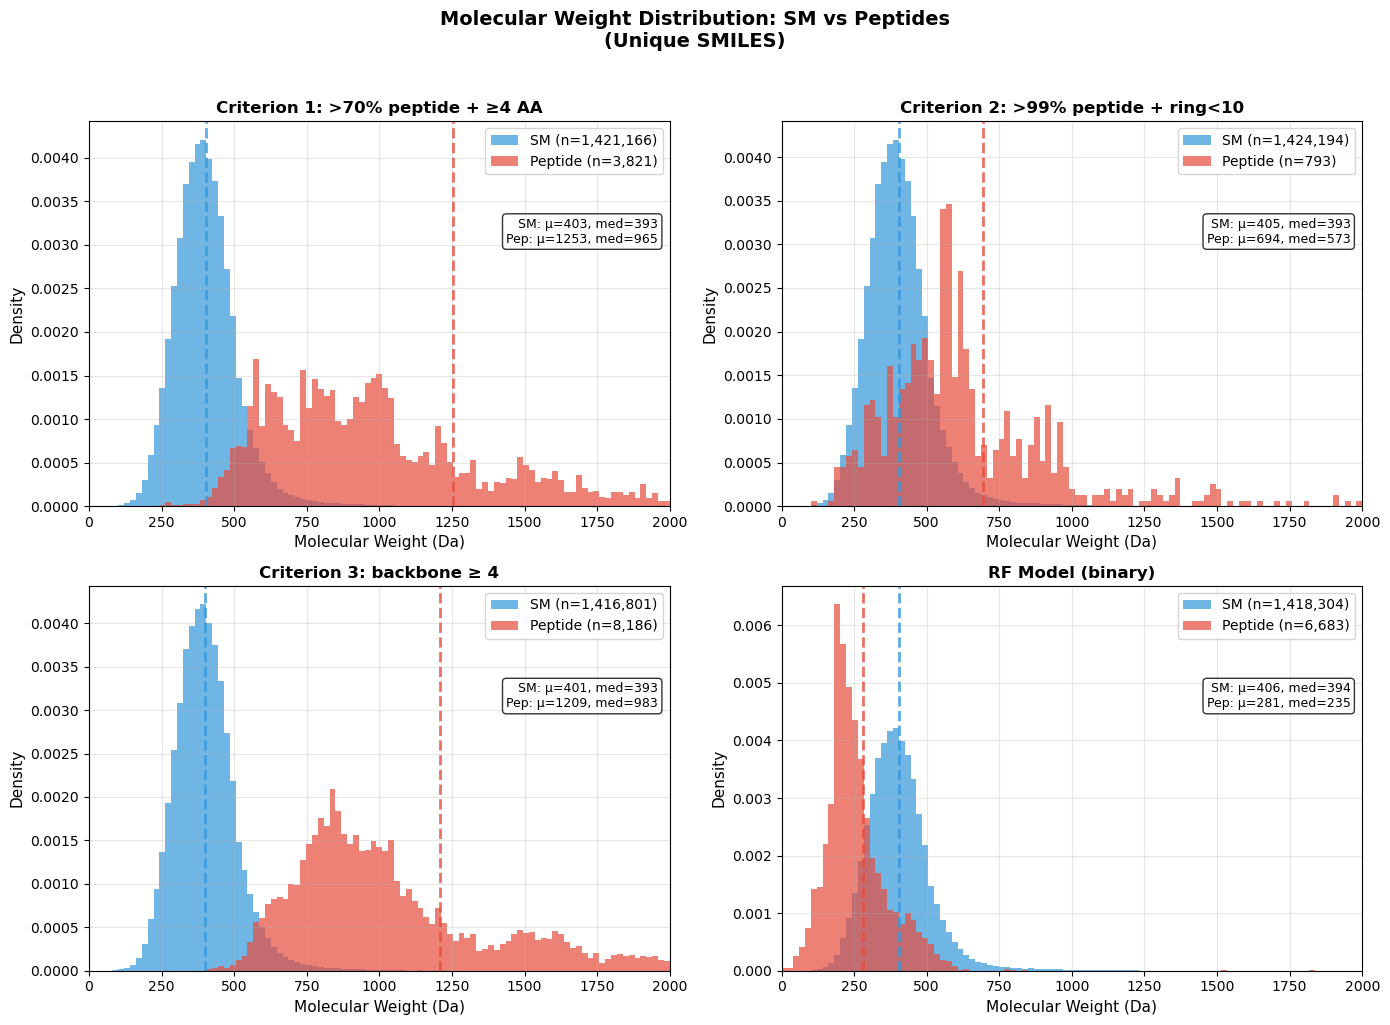


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/mw_distribution_sm_vs_peptides.png

--- MW Statistics by Classification Method ---

Criterion 1: >70% peptide + ≥4 AA:
  SM:      mean=403.2, median=393.4, n=1,421,166
  Peptide: mean=1253.1, median=965.2, n=3,821

Criterion 2: >99% peptide + ring<10:
  SM:      mean=405.4, median=393.5, n=1,424,194
  Peptide: mean=693.8, median=572.7, n=793

Criterion 3: backbone ≥ 4:
  SM:      mean=400.9, median=392.6, n=1,416,801
  Peptide: mean=1209.5, median=983.2, n=8,186

RF Model (binary):
  SM:      mean=406.1, median=393.9, n=1,418,304
  Peptide: mean=280.9, median=235.3, n=6,683


In [10]:
# =============================================================================
# STEP 5b: MW Distribution - SM vs Peptides for Each Classification
# =============================================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("STEP 5b: MW Distribution by Classification Method")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get MW data (use unique SMILES to avoid duplicates skewing the distribution)
mw_df = papyrus_df.drop_duplicates(subset='SMILES')[['SMILES', 'molecular_weight', 
    'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']].copy()
mw = mw_df['molecular_weight'].fillna(0)

# Define classification methods
methods = [
    ('class_pct70_4aa', 'Criterion 1: >70% peptide + ≥4 AA'),
    ('class_pct99_ring10', 'Criterion 2: >99% peptide + ring<10'),
    ('class_backbone4', 'Criterion 3: backbone ≥ 4'),
    ('class_rf_binary', 'RF Model (binary)')
]

for idx, (col, title) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    # Get SM and Peptide masks
    is_pep = mw_df[col] == 'peptide'
    is_sm = ~is_pep
    
    mw_sm = mw[is_sm]
    mw_pep = mw[is_pep]
    
    # Plot histograms
    bins = np.linspace(0, 2000, 100)
    
    ax.hist(mw_sm, bins=bins, alpha=0.7, label=f'SM (n={is_sm.sum():,})', 
            color='#3498db', density=True)
    ax.hist(mw_pep, bins=bins, alpha=0.7, label=f'Peptide (n={is_pep.sum():,})', 
            color='#e74c3c', density=True)
    
    ax.set_xlabel('Molecular Weight (Da)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim(0, 2000)
    ax.grid(True, alpha=0.3)
    
    # Add mean lines
    ax.axvline(mw_sm.mean(), color='#3498db', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(mw_pep.mean(), color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)
    
    # Add statistics text
    stats_text = f"SM: μ={mw_sm.mean():.0f}, med={mw_sm.median():.0f}\n"
    stats_text += f"Pep: μ={mw_pep.mean():.0f}, med={mw_pep.median():.0f}"
    ax.text(0.98, 0.75, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Molecular Weight Distribution: SM vs Peptides\n(Unique SMILES)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_distribution_sm_vs_peptides.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/mw_distribution_sm_vs_peptides.png")

# Print summary statistics
print(f"\n--- MW Statistics by Classification Method ---")
for col, title in methods:
    is_pep = mw_df[col] == 'peptide'
    mw_sm = mw[~is_pep]
    mw_pep = mw[is_pep]
    print(f"\n{title}:")
    print(f"  SM:      mean={mw_sm.mean():.1f}, median={mw_sm.median():.1f}, n={len(mw_sm):,}")
    print(f"  Peptide: mean={mw_pep.mean():.1f}, median={mw_pep.median():.1f}, n={len(mw_pep):,}")


Records with pChEMBL + classifications: 2,951,570
Unique SMILES with pChEMBL: 1,060,662


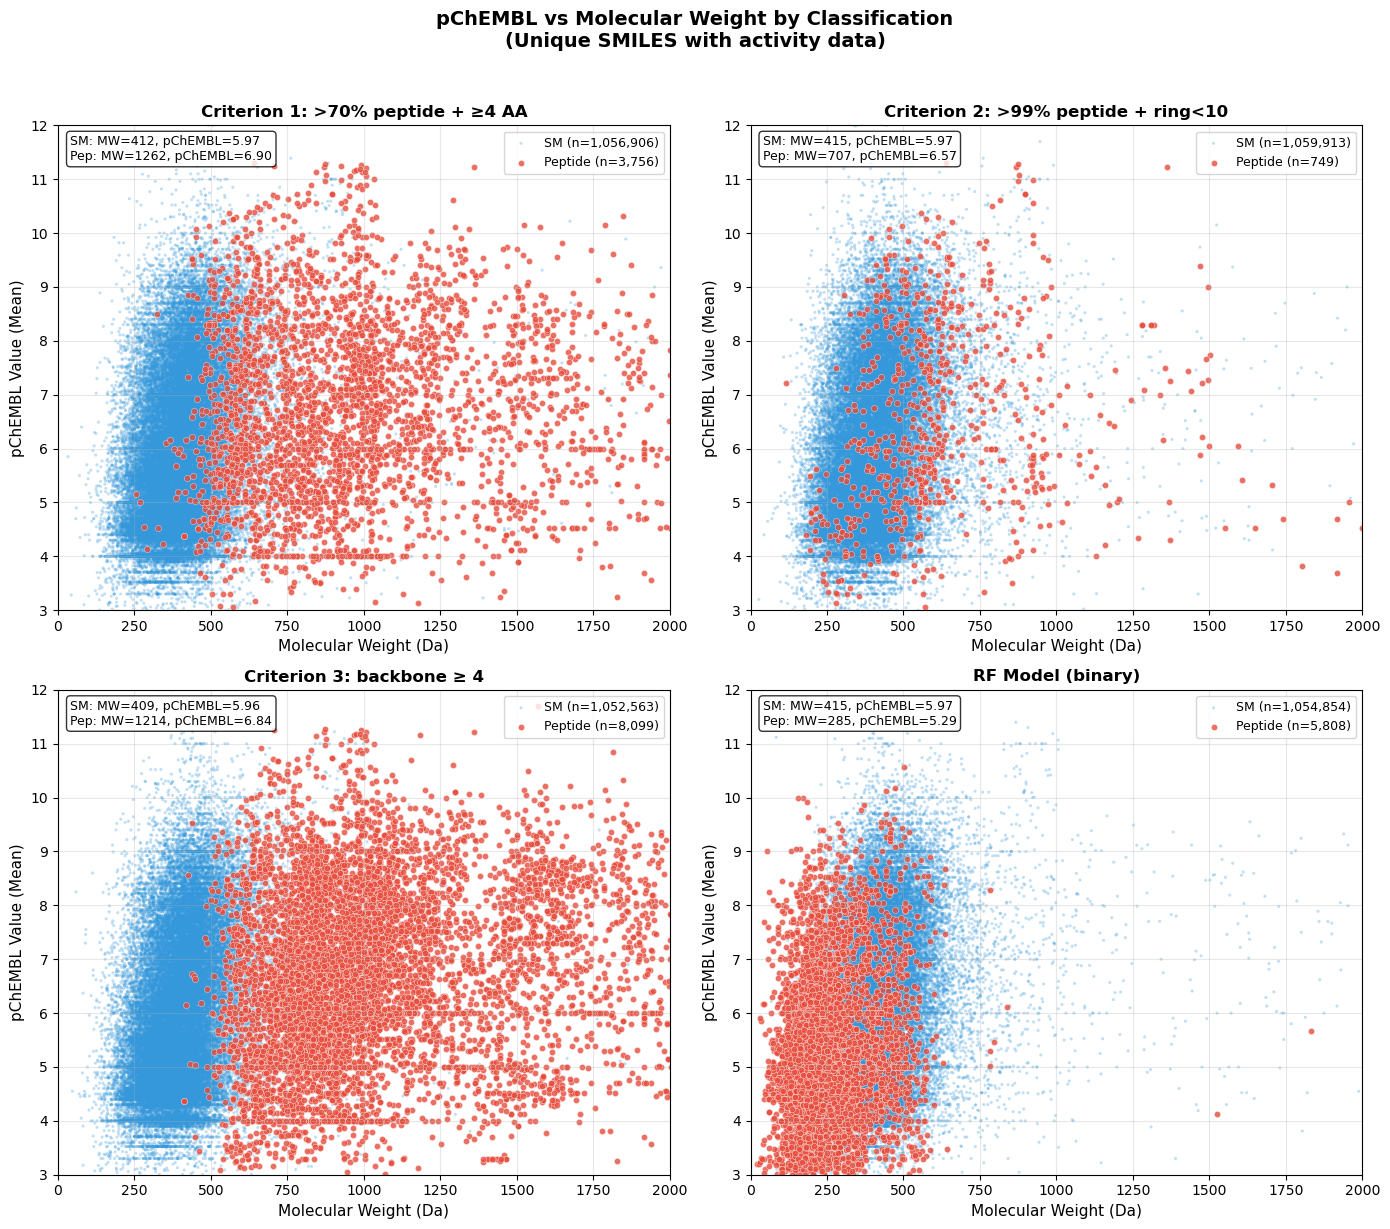


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/pchembl_vs_mw_by_classification.png

--- pChEMBL Statistics by Classification Method ---

Criterion 1: >70% peptide + ≥4 AA:
  SM:      pChEMBL mean=5.97, n=1,056,906
  Peptide: pChEMBL mean=6.90, n=3,756

Criterion 2: >99% peptide + ring<10:
  SM:      pChEMBL mean=5.97, n=1,059,913
  Peptide: pChEMBL mean=6.57, n=749

Criterion 3: backbone ≥ 4:
  SM:      pChEMBL mean=5.96, n=1,052,563
  Peptide: pChEMBL mean=6.84, n=8,099

RF Model (binary):
  SM:      pChEMBL mean=5.97, n=1,054,854
  Peptide: pChEMBL mean=5.29, n=5,808


In [12]:
# =============================================================================
# STEP 5c: pChEMBL vs MW Scatter Plot by Classification
# =============================================================================



# Filter to records with valid pchembl values and classifications
scatter_df = papyrus_df.dropna(subset=['pchembl_value_Mean', 'molecular_weight', 'class_rf_binary']).copy()
print(f"Records with pChEMBL + classifications: {len(scatter_df):,}")

# Use unique SMILES for plotting to avoid overplotting
scatter_unique = scatter_df.drop_duplicates(subset='SMILES')
print(f"Unique SMILES with pChEMBL: {len(scatter_unique):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods = [
    ('class_pct70_4aa', 'Criterion 1: >70% peptide + ≥4 AA'),
    ('class_pct99_ring10', 'Criterion 2: >99% peptide + ring<10'),
    ('class_backbone4', 'Criterion 3: backbone ≥ 4'),
    ('class_rf_binary', 'RF Model (binary)')
]

for idx, (col, title) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    # Separate SM and Peptides
    sm_mask = scatter_unique[col] == 'sm'
    pep_mask = scatter_unique[col] == 'peptide'
    
    sm_data = scatter_unique[sm_mask]
    pep_data = scatter_unique[pep_mask]
    
    # Sample SM if too many points (for performance)
    max_points = 50000
    if len(sm_data) > max_points:
        sm_sample = sm_data.sample(n=max_points, random_state=42)
    else:
        sm_sample = sm_data
    
    # Plot SM first (background), then peptides on top
    ax.scatter(sm_sample['molecular_weight'], sm_sample['pchembl_value_Mean'], 
               c='#3498db', alpha=0.3, s=5, label=f'SM (n={len(sm_data):,})', 
               edgecolors='none', rasterized=True)
    
    ax.scatter(pep_data['molecular_weight'], pep_data['pchembl_value_Mean'], 
               c='#e74c3c', alpha=0.8, s=20, label=f'Peptide (n={len(pep_data):,})', 
               edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel('Molecular Weight (Da)', fontsize=11)
    ax.set_ylabel('pChEMBL Value (Mean)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, 2000)
    ax.set_ylim(3, 12)
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    if len(pep_data) > 0:
        stats_text = f"SM: MW={sm_data['molecular_weight'].mean():.0f}, pChEMBL={sm_data['pchembl_value_Mean'].mean():.2f}\n"
        stats_text += f"Pep: MW={pep_data['molecular_weight'].mean():.0f}, pChEMBL={pep_data['pchembl_value_Mean'].mean():.2f}"
    else:
        stats_text = f"SM: MW={sm_data['molecular_weight'].mean():.0f}, pChEMBL={sm_data['pchembl_value_Mean'].mean():.2f}\n"
        stats_text += "Pep: n=0"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('pChEMBL vs Molecular Weight by Classification\n(Unique SMILES with activity data)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_vs_mw_by_classification.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/pchembl_vs_mw_by_classification.png")

# Print summary statistics
print(f"\n--- pChEMBL Statistics by Classification Method ---")
for col, title in methods:
    sm_data = scatter_unique[scatter_unique[col] == 'sm']
    pep_data = scatter_unique[scatter_unique[col] == 'peptide']
    print(f"\n{title}:")
    print(f"  SM:      pChEMBL mean={sm_data['pchembl_value_Mean'].mean():.2f}, n={len(sm_data):,}")
    if len(pep_data) > 0:
        print(f"  Peptide: pChEMBL mean={pep_data['pchembl_value_Mean'].mean():.2f}, n={len(pep_data):,}")
    else:
        print(f"  Peptide: n=0")


STEP 5d: MW vs Peptide Backbone Length
Unique SMILES with MW + backbone length: 1,424,982


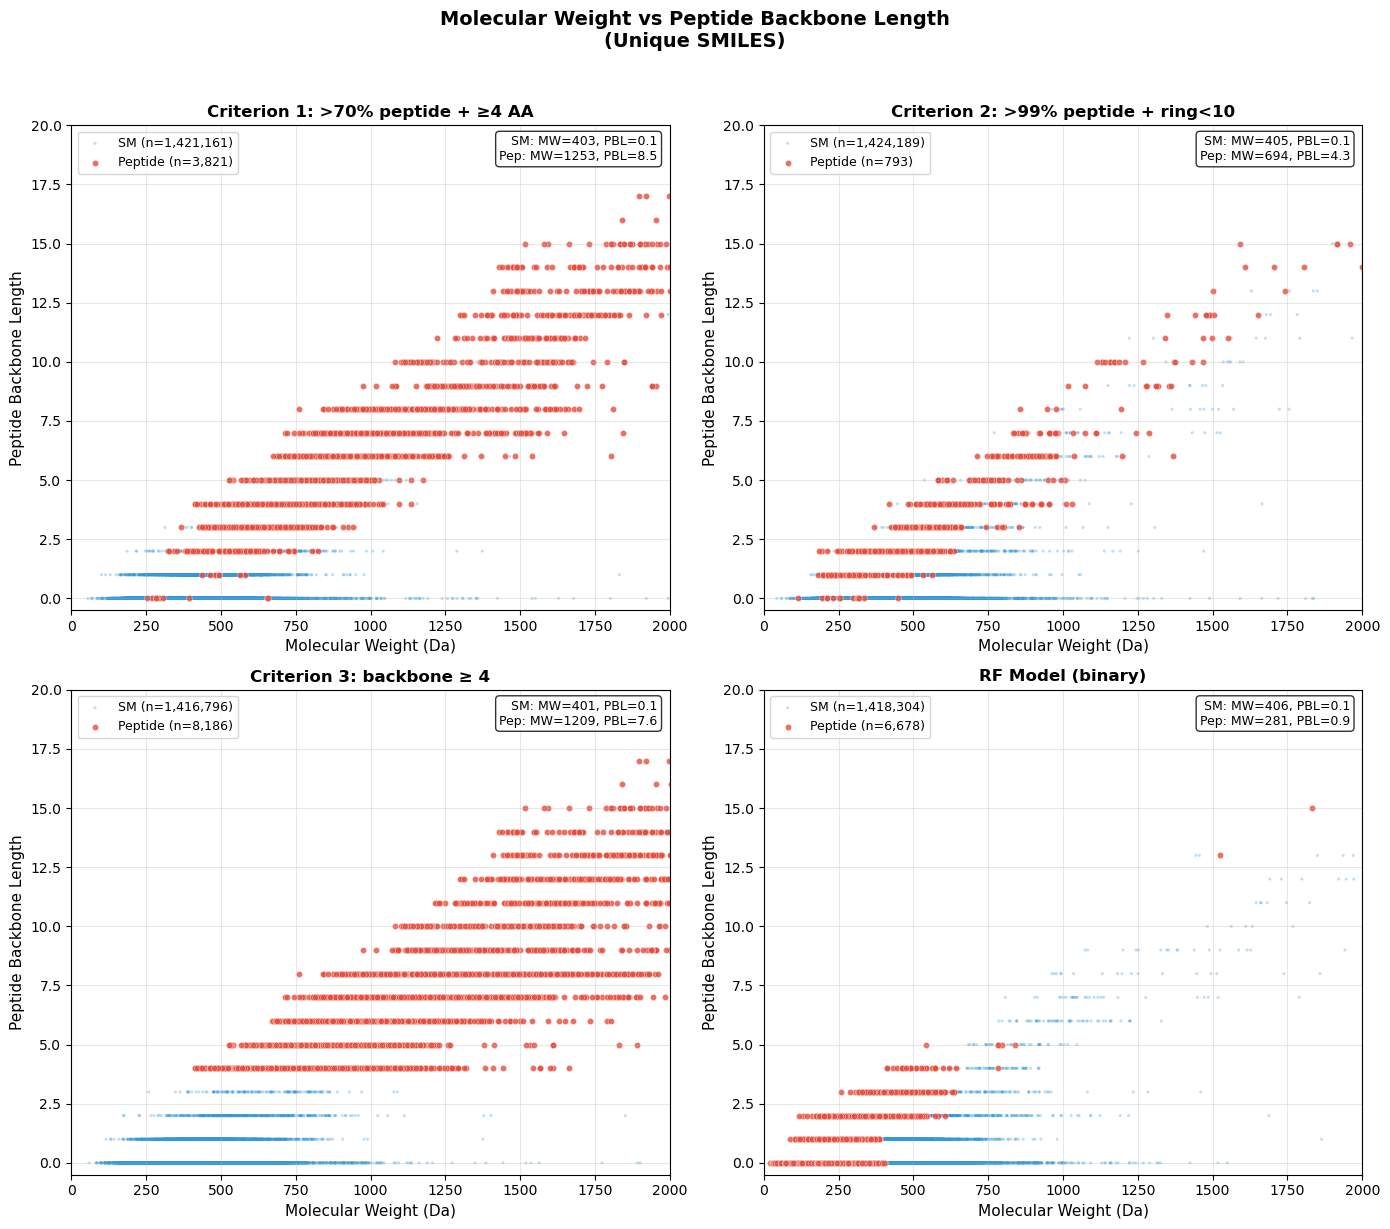


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/mw_vs_peptide_length.png

--- Peptide Backbone Length by Classification ---

Criterion 1: >70% peptide + ≥4 AA:
  SM:      mean PBL=0.09, max=37
  Peptide: mean PBL=8.47, max=55

Criterion 2: >99% peptide + ring<10:
  SM:      mean PBL=0.11, max=55
  Peptide: mean PBL=4.31, max=36

Criterion 3: backbone ≥ 4:
  SM:      mean PBL=0.07, max=3
  Peptide: mean PBL=7.57, max=55

RF Model (binary):
  SM:      mean PBL=0.11, max=55
  Peptide: mean PBL=0.88, max=37


In [13]:
# =============================================================================
# STEP 5d: MW vs Peptide Backbone Length by Classification
# =============================================================================

print("=" * 80)
print("STEP 5d: MW vs Peptide Backbone Length")
print("=" * 80)

# Get unique SMILES with features
plot_df = papyrus_df.drop_duplicates(subset='SMILES')[
    ['SMILES', 'molecular_weight', 'peptide_backbone_length', 
     'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
].copy()
plot_df = plot_df.dropna(subset=['molecular_weight', 'peptide_backbone_length'])
print(f"Unique SMILES with MW + backbone length: {len(plot_df):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods = [
    ('class_pct70_4aa', 'Criterion 1: >70% peptide + ≥4 AA'),
    ('class_pct99_ring10', 'Criterion 2: >99% peptide + ring<10'),
    ('class_backbone4', 'Criterion 3: backbone ≥ 4'),
    ('class_rf_binary', 'RF Model (binary)')
]

for idx, (col, title) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    # Separate SM and Peptides
    sm_data = plot_df[plot_df[col] == 'sm']
    pep_data = plot_df[plot_df[col] == 'peptide']
    
    # Sample SM if too many points
    max_points = 50000
    if len(sm_data) > max_points:
        sm_sample = sm_data.sample(n=max_points, random_state=42)
    else:
        sm_sample = sm_data
    
    # Plot SM first, then peptides on top
    ax.scatter(sm_sample['molecular_weight'], sm_sample['peptide_backbone_length'], 
               c='#3498db', alpha=0.3, s=5, label=f'SM (n={len(sm_data):,})', 
               edgecolors='none', rasterized=True)
    
    ax.scatter(pep_data['molecular_weight'], pep_data['peptide_backbone_length'], 
               c='#e74c3c', alpha=0.8, s=20, label=f'Peptide (n={len(pep_data):,})', 
               edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel('Molecular Weight (Da)', fontsize=11)
    ax.set_ylabel('Peptide Backbone Length', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0, 2000)
    ax.set_ylim(-0.5, max(20, plot_df['peptide_backbone_length'].quantile(0.99) + 2))
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    sm_pbl = sm_data['peptide_backbone_length']
    pep_pbl = pep_data['peptide_backbone_length']
    
    stats_text = f"SM: MW={sm_data['molecular_weight'].mean():.0f}, PBL={sm_pbl.mean():.1f}\n"
    if len(pep_data) > 0:
        stats_text += f"Pep: MW={pep_data['molecular_weight'].mean():.0f}, PBL={pep_pbl.mean():.1f}"
    else:
        stats_text += "Pep: n=0"
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Molecular Weight vs Peptide Backbone Length\n(Unique SMILES)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_vs_peptide_length.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/mw_vs_peptide_length.png")

# Print summary
print(f"\n--- Peptide Backbone Length by Classification ---")
for col, title in methods:
    sm_data = plot_df[plot_df[col] == 'sm']
    pep_data = plot_df[plot_df[col] == 'peptide']
    print(f"\n{title}:")
    print(f"  SM:      mean PBL={sm_data['peptide_backbone_length'].mean():.2f}, max={sm_data['peptide_backbone_length'].max():.0f}")
    if len(pep_data) > 0:
        print(f"  Peptide: mean PBL={pep_data['peptide_backbone_length'].mean():.2f}, max={pep_data['peptide_backbone_length'].max():.0f}")
    else:
        print(f"  Peptide: n=0")


STEP 5e: MW vs Peptide Bond Count
Unique SMILES with MW + peptide bond count: 1,424,982


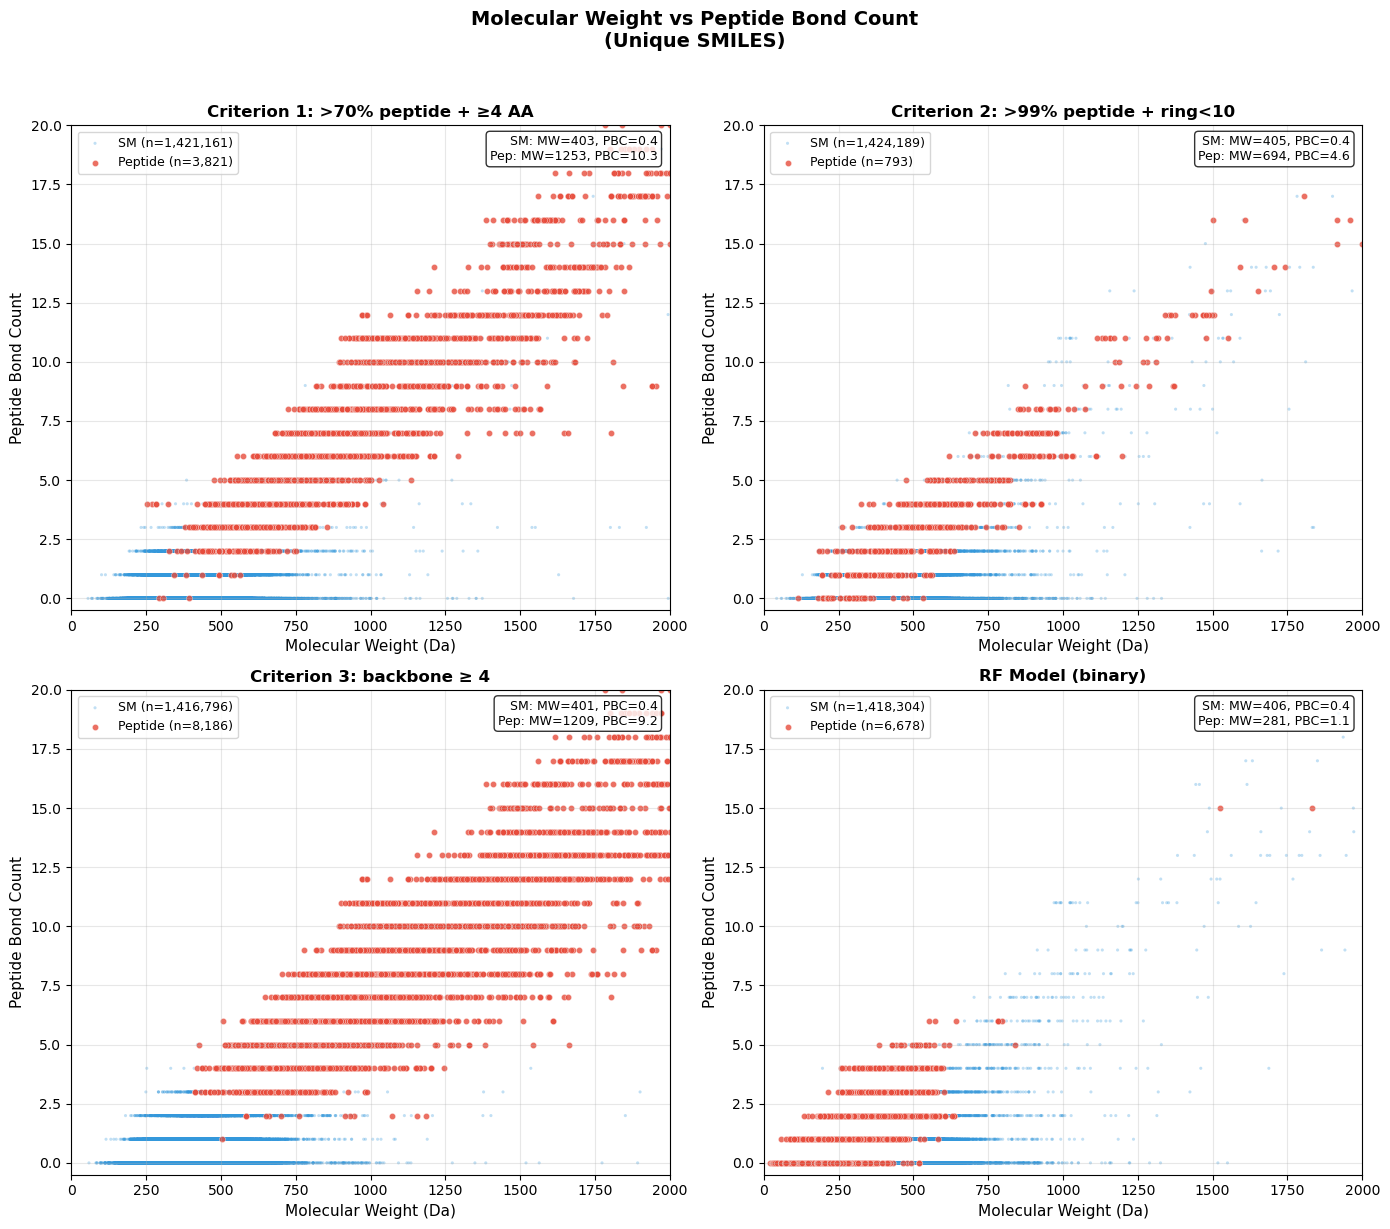


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/mw_vs_peptide_bonds.png

--- Peptide Bond Count by Classification ---

Criterion 1: >70% peptide + ≥4 AA:
  SM:      mean PBC=0.42, max=49
  Peptide: mean PBC=10.26, max=55

Criterion 2: >99% peptide + ring<10:
  SM:      mean PBC=0.44, max=55
  Peptide: mean PBC=4.64, max=43

Criterion 3: backbone ≥ 4:
  SM:      mean PBC=0.39, max=28
  Peptide: mean PBC=9.24, max=55

RF Model (binary):
  SM:      mean PBC=0.44, max=55
  Peptide: mean PBC=1.05, max=41


In [ ]:
# =============================================================================
# STEP 5e: MW vs Peptide Bond Count by Classification
# =============================================================================

print("=" * 80)
print("STEP 5e: MW vs Peptide Bond Count")
print("=" * 80)

# Get unique SMILES with features
plot_df = papyrus_df.drop_duplicates(subset='SMILES')[
    ['SMILES', 'molecular_weight', 'peptide_bond_count', 
     'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
].copy()
plot_df = plot_df.dropna(subset=['molecular_weight', 'peptide_bond_count'])
print(f"Unique SMILES with MW + peptide bond count: {len(plot_df):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods = [
    ('class_pct70_4aa', 'Criterion 1: >70% peptide + ≥4 AA'),
    ('class_pct99_ring10', 'Criterion 2: >99% peptide + ring<10'),
    ('class_backbone4', 'Criterion 3: backbone ≥ 4'),
    ('class_rf_binary', 'RF Model (binary)')
]

for idx, (col, title) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    # Separate SM and Peptides
    sm_data = plot_df[plot_df[col] == 'sm']
    pep_data = plot_df[plot_df[col] == 'peptide']
    
    # Sample SM if too many points
    max_points = 50000
    if len(sm_data) > max_points:
        sm_sample = sm_data.sample(n=max_points, random_state=42)
    else:
        sm_sample = sm_data
    
    # Plot SM first, then peptides on top
    ax.scatter(sm_sample['molecular_weight'], sm_sample['peptide_bond_count'], 
               c='#3498db', alpha=0.3, s=5, label=f'SM (n={len(sm_data):,})', 
               edgecolors='none', rasterized=True)
    
    ax.scatter(pep_data['molecular_weight'], pep_data['peptide_bond_count'], 
               c='#e74c3c', alpha=0.8, s=20, label=f'Peptide (n={len(pep_data):,})', 
               edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel('Molecular Weight (Da)', fontsize=11)
    ax.set_ylabel('Peptide Bond Count', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0, 2000)
    ax.set_ylim(-0.5, max(20, plot_df['peptide_bond_count'].quantile(0.99) + 2))
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    sm_pbc = sm_data['peptide_bond_count']
    pep_pbc = pep_data['peptide_bond_count']
    
    stats_text = f"SM: MW={sm_data['molecular_weight'].mean():.0f}, PBC={sm_pbc.mean():.1f}\n"
    if len(pep_data) > 0:
        stats_text += f"Pep: MW={pep_data['molecular_weight'].mean():.0f}, PBC={pep_pbc.mean():.1f}"
    else:
        stats_text += "Pep: n=0"
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Molecular Weight vs Peptide Bond Count\n(Unique SMILES)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_vs_peptide_bonds.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/mw_vs_peptide_bonds.png")

# Print summary
print(f"\n--- Peptide Bond Count by Classification ---")
for col, title in methods:
    sm_data = plot_df[plot_df[col] == 'sm']
    pep_data = plot_df[plot_df[col] == 'peptide']
    print(f"\n{title}:")
    print(f"  SM:      mean PBC={sm_data['peptide_bond_count'].mean():.2f}, max={sm_data['peptide_bond_count'].max():.0f}")
    if len(pep_data) > 0:
        print(f"  Peptide: mean PBC={pep_data['peptide_bond_count'].mean():.2f}, max={pep_data['peptide_bond_count'].max():.0f}")
    else:
        print(f"  Peptide: n=0")


In [30]:
# =============================================================================
# STEP 5f: Target-level Analysis - Peptides vs SM per Target
# =============================================================================

print("=" * 80)
print("STEP 5f: Target-level Analysis - Peptides per Target")
print("=" * 80)

# Group by accession and count peptides/SM for each criteria
class_cols = ['class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
saved_files = []

for col in class_cols:
    print(f"\n" + "=" * 80)
    print(f"TOP 100 TARGETS by Peptide Count: {col}")
    print("=" * 80)
    
    # Count peptides and SM per target
    target_stats = papyrus_df.groupby('accession')[col].value_counts().unstack(fill_value=0)
    
    # Ensure both columns exist
    if 'peptide' not in target_stats.columns:
        target_stats['peptide'] = 0
    if 'sm' not in target_stats.columns:
        target_stats['sm'] = 0
    
    target_stats = target_stats[['peptide', 'sm']].copy()
    target_stats['total'] = target_stats['peptide'] + target_stats['sm']
    target_stats['pct_peptide'] = (target_stats['peptide'] / target_stats['total'] * 100).round(2)
    
    # Sort by peptide count
    target_stats = target_stats.sort_values('peptide', ascending=False)
    
    # Add rank column
    target_stats_save = target_stats.reset_index()
    target_stats_save.insert(0, 'rank', range(1, len(target_stats_save) + 1))
    
    # Save to file (CSV format)
    output_file = f"{OUTPUT_DIR}/top_targets_{col}.csv"
    target_stats_save.to_csv(output_file, index=False)
    saved_files.append(output_file)
    print(f"Saved all {len(target_stats):,} targets to: {output_file}")
    
    # Print top 100
    print(f"\n{'Rank':<6} {'Accession':<15} {'Peptides':>10} {'SM':>10} {'Total':>10} {'%Peptide':>10}")
    print("-" * 65)
    
    for i, (acc, row) in enumerate(target_stats.head(100).iterrows()):
        print(f"{i+1:<6} {acc:<15} {int(row['peptide']):>10,} {int(row['sm']):>10,} {int(row['total']):>10,} {row['pct_peptide']:>9.2f}%")
    
    # Summary stats
    targets_with_peptides = (target_stats['peptide'] > 0).sum()
    print(f"\n--- Summary for {col} ---")
    print(f"Total targets: {len(target_stats):,}")
    print(f"Targets with at least 1 peptide: {targets_with_peptides:,} ({targets_with_peptides/len(target_stats)*100:.1f}%)")
    print(f"Targets with 0 peptides: {len(target_stats) - targets_with_peptides:,}")
    
    if targets_with_peptides > 0:
        pep_targets = target_stats[target_stats['peptide'] > 0]
        print(f"\nAmong targets with peptides:")
        print(f"  Mean peptides per target: {pep_targets['peptide'].mean():.1f}")
        print(f"  Median peptides per target: {pep_targets['peptide'].median():.0f}")
        print(f"  Max peptides per target: {pep_targets['peptide'].max():,} ({pep_targets['peptide'].idxmax()})")

print(f"\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


STEP 5f: Target-level Analysis - Peptides per Target

TOP 100 TARGETS by Peptide Count: class_pct70_4aa
Saved all 6,926 targets to: /fsx/amira/papyrus_50.5_results/features_only/top_targets_class_pct70_4aa.csv

Rank   Accession         Peptides         SM      Total   %Peptide
-----------------------------------------------------------------
1      P33535                 500      1,822      2,322     21.53%
2      P33533                 372      1,377      1,749     21.27%
3      P32300                 343        639        982     34.93%
4      P97266                 233        864      1,097     21.24%
5      P41143                 228      4,463      4,691      4.86%
6      P30559                 226    320,529    320,755      0.07%
7      P35372                 185      7,361      7,546      2.45%
8      P43220                 167    301,686    301,853      0.06%
9      P37288                 152    320,148    320,300      0.05%
10     P47901                 105        668        7

STEP 5g: Visualize Molecules from Top Targets

Criterion 1 (pct70+4AA): class_pct70_4aa

--- Target: P33535 (500 peptides, 1822 SM) ---

Peptides (showing 6 of 500):


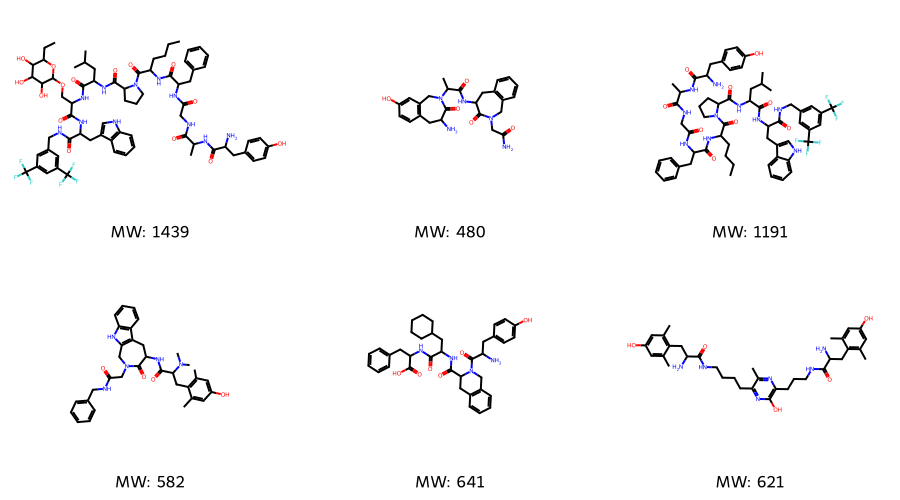


Small Molecules (showing 6 of 1822):


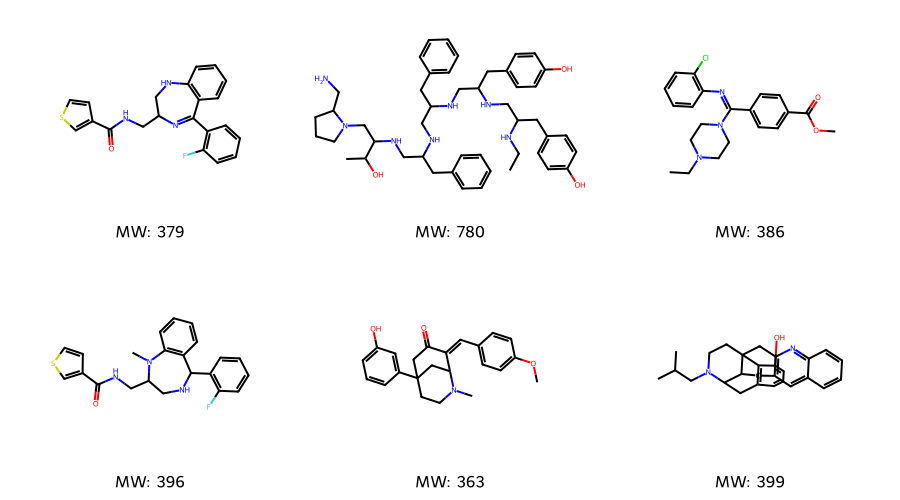


--- Target: P33533 (372 peptides, 1377 SM) ---

Peptides (showing 6 of 372):


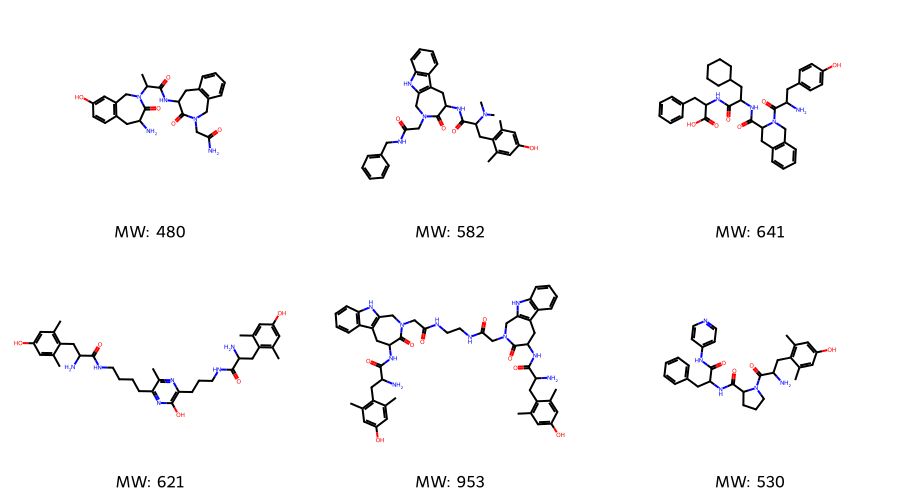


Small Molecules (showing 6 of 1377):


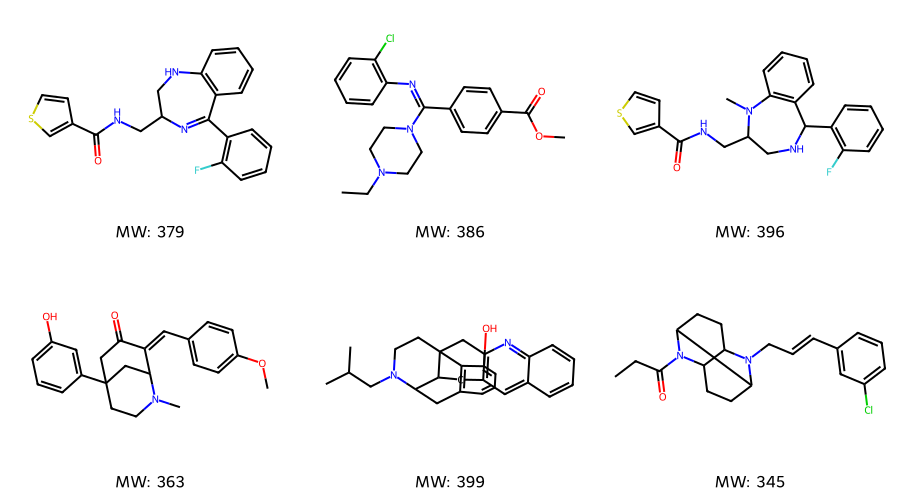


Criterion 2 (pct99+ring<10): class_pct99_ring10

--- Target: P33535 (290 peptides, 2032 SM) ---

Peptides (showing 6 of 290):


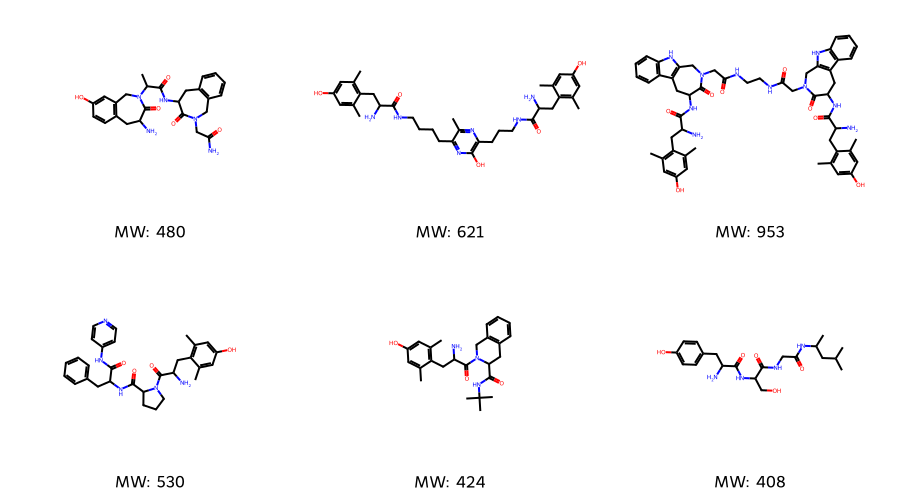


Small Molecules (showing 6 of 2032):


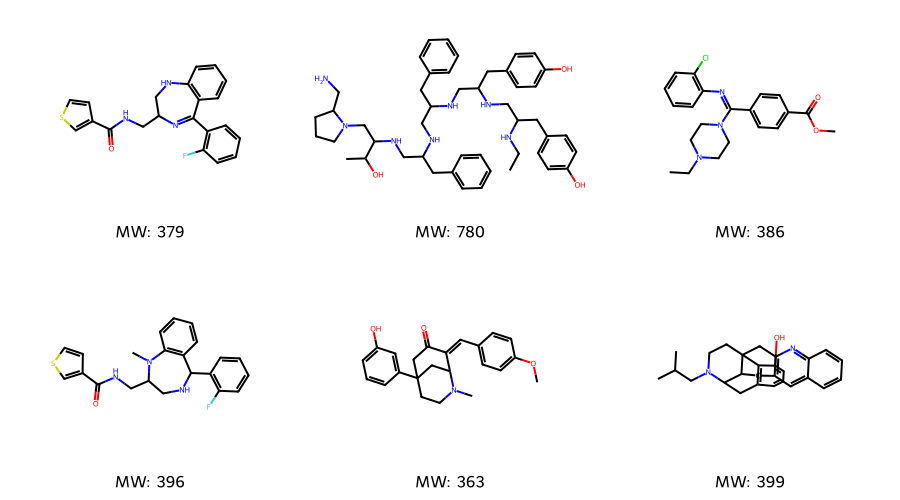


--- Target: P33533 (238 peptides, 1511 SM) ---

Peptides (showing 6 of 238):


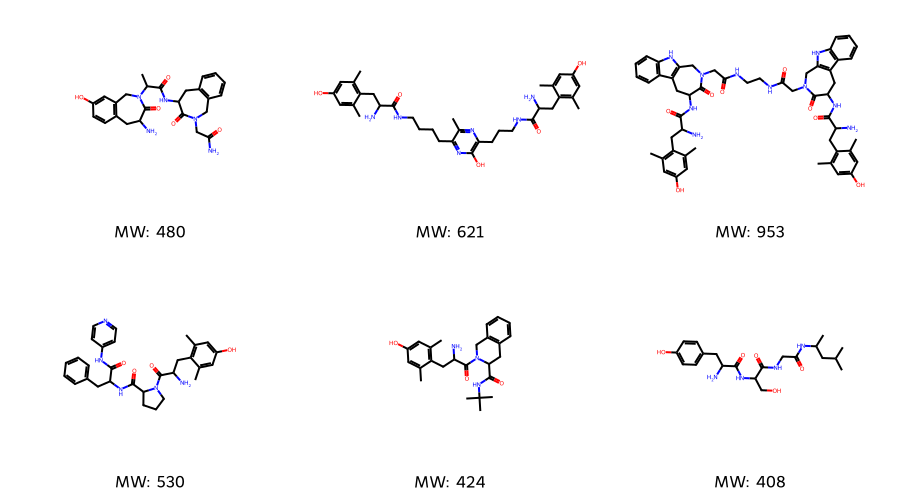


Small Molecules (showing 6 of 1511):


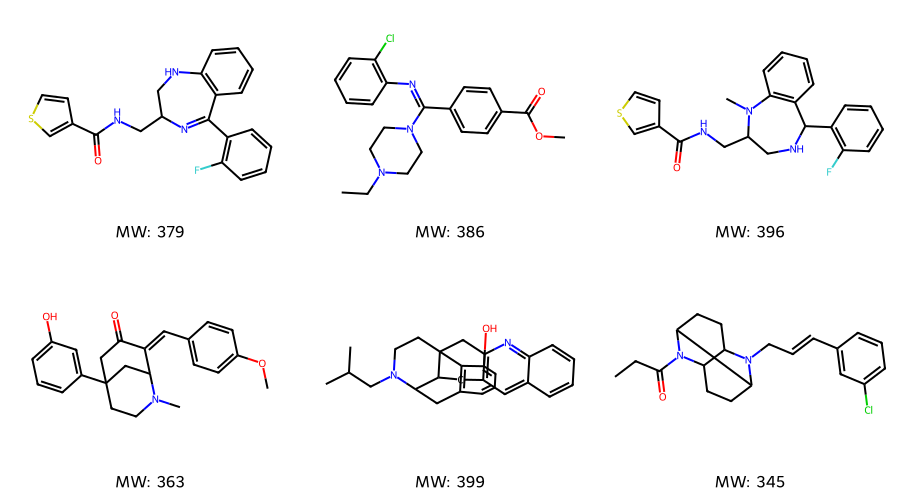


Criterion 3 (backbone>=4): class_backbone4

--- Target: P32245 (533 peptides, 351305 SM) ---

Peptides (showing 6 of 533):


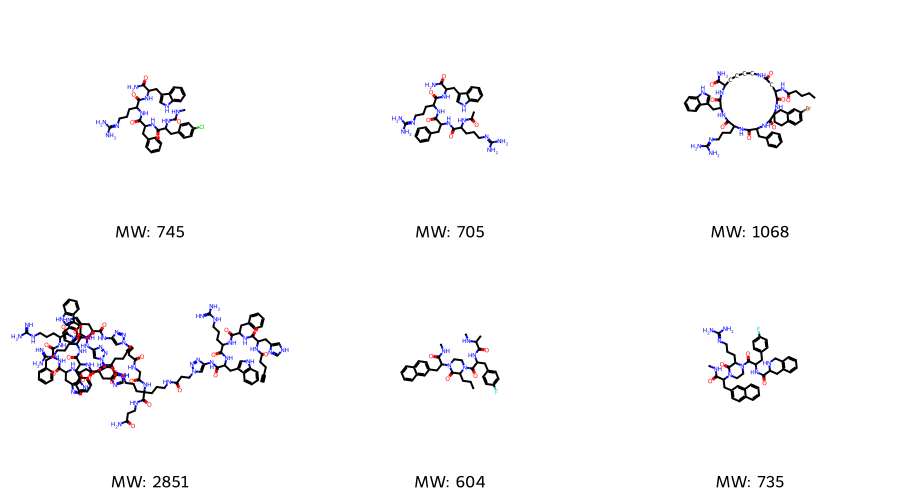


Small Molecules (showing 6 of 351305):


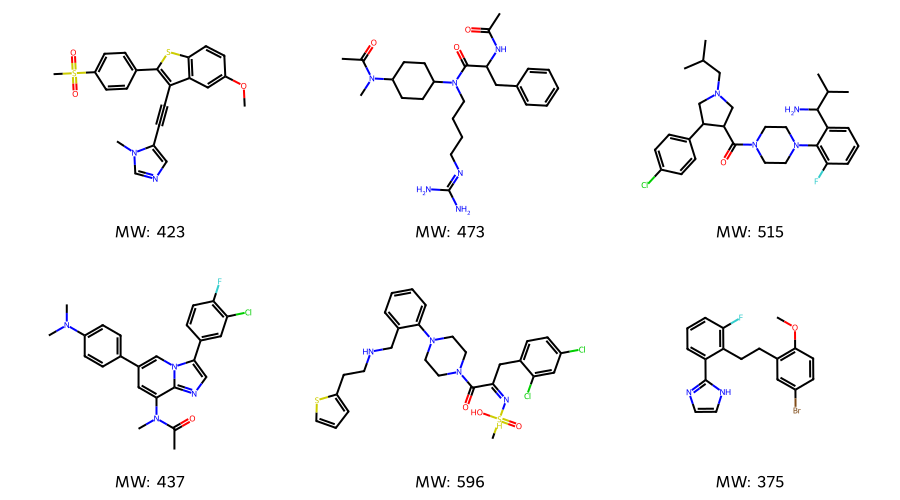


--- Target: P33535 (355 peptides, 1967 SM) ---

Peptides (showing 6 of 355):


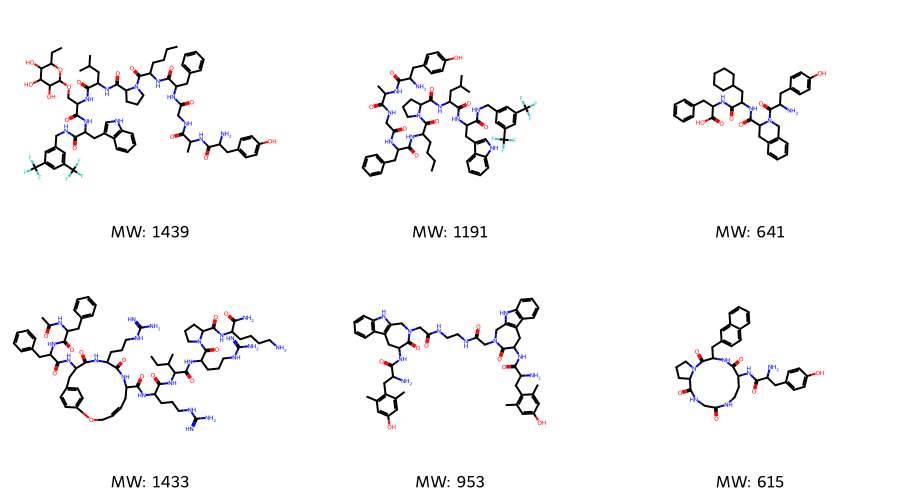


Small Molecules (showing 6 of 1967):


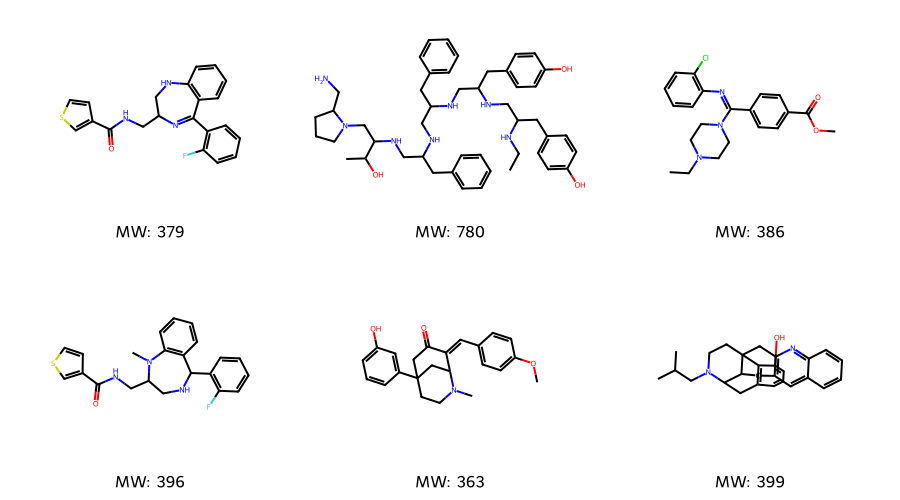


RF Model: class_rf_binary

--- Target: P11473 (1106 peptides, 367324 SM) ---

Peptides (showing 6 of 1106):


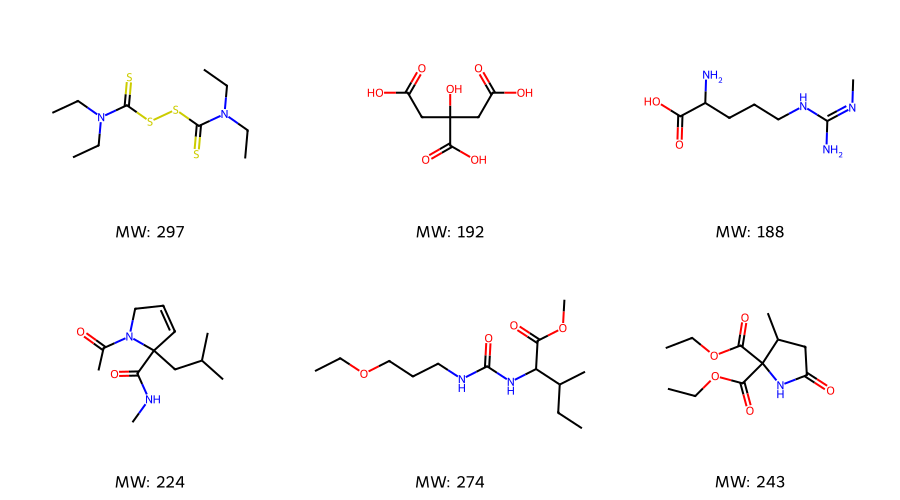


Small Molecules (showing 6 of 367324):


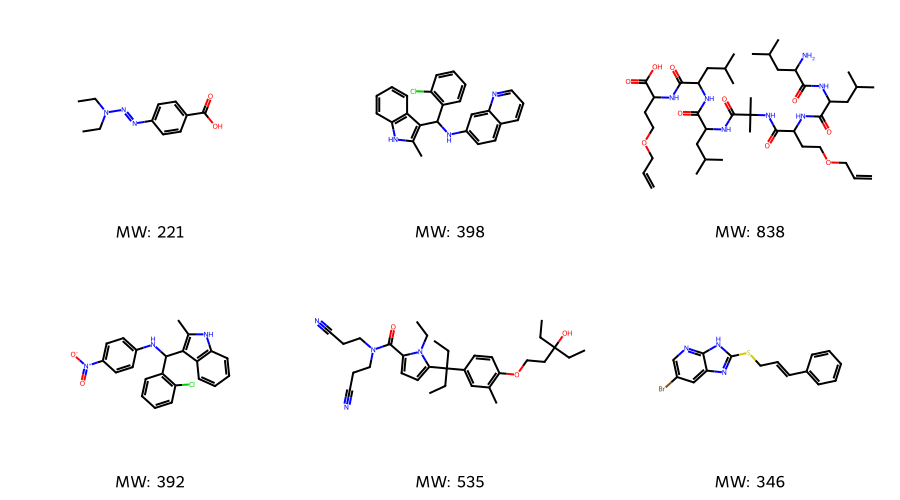


--- Target: P35869 (1018 peptides, 314413 SM) ---

Peptides (showing 6 of 1018):


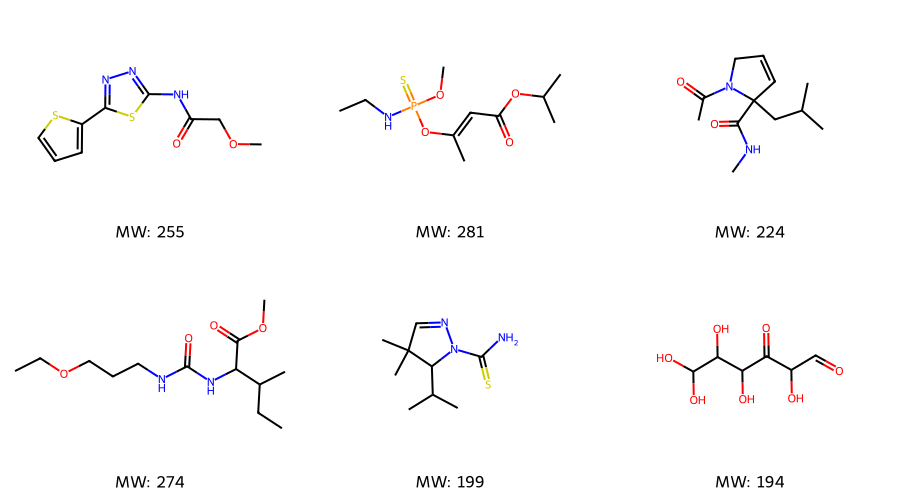


Small Molecules (showing 6 of 314413):


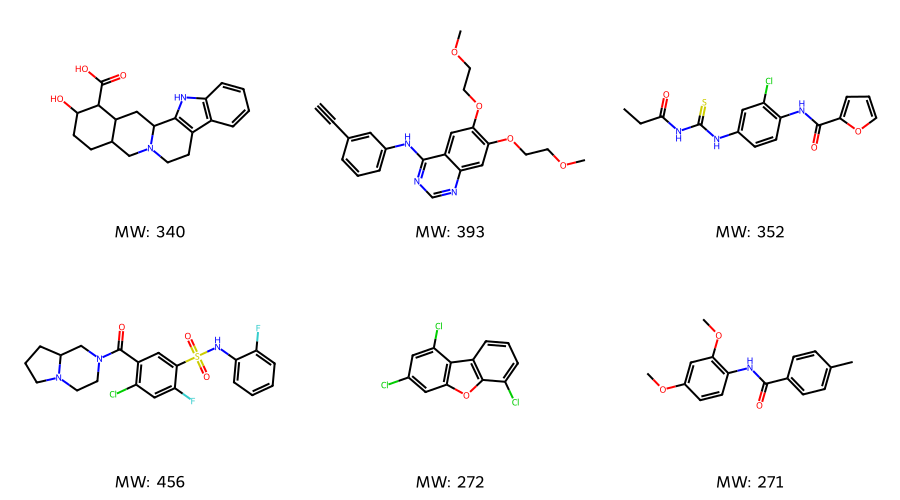


VISUALIZATION COMPLETE


In [17]:
# =============================================================================
# STEP 5g: Visualize Molecules from Top Targets
# =============================================================================

from rdkit.Chem import Draw
from rdkit import Chem

print("=" * 80)
print("STEP 5g: Visualize Molecules from Top Targets")
print("=" * 80)

# For each classification, get top target and show some peptides vs SM
class_cols = ['class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
class_names = ['Criterion 1 (pct70+4AA)', 'Criterion 2 (pct99+ring<10)', 
               'Criterion 3 (backbone>=4)', 'RF Model']

for col, name in zip(class_cols, class_names):
    print(f"\n" + "=" * 80)
    print(f"{name}: {col}")
    print("=" * 80)
    
    # Get target stats
    target_stats = papyrus_df.groupby('accession')[col].value_counts().unstack(fill_value=0)
    if 'peptide' not in target_stats.columns:
        target_stats['peptide'] = 0
    if 'sm' not in target_stats.columns:
        target_stats['sm'] = 0
    target_stats = target_stats.sort_values('peptide', ascending=False)
    
    # Get top target with peptides
    top_targets = target_stats[target_stats['peptide'] > 0].head(3)
    
    if len(top_targets) == 0:
        print("No targets with peptides for this criterion")
        continue
    
    for target in top_targets.index[:2]:  # Top 2 targets
        n_pep = int(target_stats.loc[target, 'peptide'])
        n_sm = int(target_stats.loc[target, 'sm'])
        
        print(f"\n--- Target: {target} ({n_pep} peptides, {n_sm} SM) ---")
        
        # Get unique SMILES for this target
        target_data = papyrus_df[papyrus_df['accession'] == target].drop_duplicates(subset='SMILES')
        
        # Get peptides
        pep_smiles = target_data[target_data[col] == 'peptide']['SMILES'].head(6).tolist()
        # Get SM
        sm_smiles = target_data[target_data[col] == 'sm']['SMILES'].head(6).tolist()
        
        # Create molecules
        pep_mols = [Chem.MolFromSmiles(s) for s in pep_smiles if s]
        pep_mols = [m for m in pep_mols if m is not None]
        
        sm_mols = [Chem.MolFromSmiles(s) for s in sm_smiles if s]
        sm_mols = [m for m in sm_mols if m is not None]
        
        # Plot peptides
        if pep_mols:
            print(f"\nPeptides (showing {len(pep_mols)} of {n_pep}):")
            img = Draw.MolsToGridImage(pep_mols[:6], molsPerRow=3, subImgSize=(300, 250),
                                       legends=[f"MW: {Chem.Descriptors.MolWt(m):.0f}" for m in pep_mols[:6]])
            display(img)
        
        # Plot SM
        if sm_mols:
            print(f"\nSmall Molecules (showing {len(sm_mols)} of {n_sm}):")
            img = Draw.MolsToGridImage(sm_mols[:6], molsPerRow=3, subImgSize=(300, 250),
                                       legends=[f"MW: {Chem.Descriptors.MolWt(m):.0f}" for m in sm_mols[:6]])
            display(img)

print(f"\n" + "=" * 80)
print("VISUALIZATION COMPLETE")
print("=" * 80)


In [31]:
# =============================================================================
# STEP 5h: Check Overlap with Target Prioritization List
# =============================================================================

print("=" * 80)
print("STEP 5h: Overlap with Target Prioritization List")
print("=" * 80)

# Read the target prioritization file
target_file = "/fsx/amira/papyrus_target_prioritization/TargetPrioritization_PBS_IDs_Nov2025.csv"
target_df = pd.read_csv(target_file)
print(f"Loaded {len(target_df)} prioritized targets")

# Extract UniProt IDs
def extract_uniprot_ids(uid_string):
    """Extract UniProt IDs from potentially complex strings."""
    if pd.isna(uid_string):
        return []
    ids = []
    for part in str(uid_string).replace('+', ' ').replace(',', ' ').split():
        part = part.strip()
        if part and len(part) >= 6 and part[0] in 'PQOA':
            ids.append(part)
    return ids

all_uniprot_ids = []
for uid in target_df['Uniprot ID']:
    all_uniprot_ids.extend(extract_uniprot_ids(uid))
priority_targets = set(all_uniprot_ids)
print(f"Unique UniProt IDs in priority list: {len(priority_targets)}")

# Check overlap for each classification criteria
class_cols = ['class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
class_names = ['Criterion 1 (pct70+4AA)', 'Criterion 2 (pct99+ring<10)', 
               'Criterion 3 (backbone>=4)', 'RF Model (binary)']

print(f"\n" + "=" * 80)
print("OVERLAP ANALYSIS: Priority Targets in Top 100 by Peptide Count")
print("=" * 80)

for col, name in zip(class_cols, class_names):
    # Get target stats
    target_stats = papyrus_df.groupby('accession')[col].value_counts().unstack(fill_value=0)
    if 'peptide' not in target_stats.columns:
        target_stats['peptide'] = 0
    if 'sm' not in target_stats.columns:
        target_stats['sm'] = 0
    target_stats = target_stats[['peptide', 'sm']].copy()
    target_stats['total'] = target_stats['peptide'] + target_stats['sm']
    target_stats['pct_peptide'] = (target_stats['peptide'] / target_stats['total'] * 100).round(2)
    target_stats = target_stats.sort_values('peptide', ascending=False)
    
    # Get top 100 accessions
    top100_accessions = set(target_stats.head(100).index)
    
    # Find overlap
    overlap = priority_targets.intersection(top100_accessions)
    
    print(f"\n--- {name} ---")
    print(f"Top 100 targets by peptide count")
    print(f"Overlap with {len(priority_targets)} priority targets: {len(overlap)}")
    
    # Collect overlap data for saving
    overlap_rows = []
    if overlap:
        print(f"\nOverlapping targets:")
        for acc in sorted(overlap):
            row = target_stats.loc[acc]
            rank = list(target_stats.index).index(acc) + 1
            # Get gene name if available
            gene_match = target_df[target_df['Uniprot ID'].astype(str).str.contains(acc, na=False)]
            gene_name = gene_match['Gene name'].values[0] if len(gene_match) > 0 else "N/A"
            print(f"  Rank {rank:>3}: {acc} ({gene_name}) - {int(row['peptide'])} peptides, {int(row['sm'])} SM ({row['pct_peptide']:.1f}%)")
            overlap_rows.append({
                'rank': rank,
                'accession': acc,
                'gene_name': gene_name,
                'peptides': int(row['peptide']),
                'sm': int(row['sm']),
                'total': int(row['total']),
                'pct_peptide': row['pct_peptide'],
                'criterion': col
            })
    else:
        print("  No overlap found")
    
    # Save overlap data for this criterion
    if overlap_rows:
        overlap_df = pd.DataFrame(overlap_rows)
        overlap_file = f"{OUTPUT_DIR}/priority_targets_overlap_{col}.csv"
        overlap_df.to_csv(overlap_file, index=False)
        print(f"  Saved overlap to: {overlap_file}")





STEP 5h: Overlap with Target Prioritization List
Loaded 56 prioritized targets
Unique UniProt IDs in priority list: 55

OVERLAP ANALYSIS: Priority Targets in Top 100 by Peptide Count

--- Criterion 1 (pct70+4AA) ---
Top 100 targets by peptide count
Overlap with 55 priority targets: 23

Overlapping targets:
  Rank  48: O95838 (GLP2R) - 44 peptides, 0 SM (100.0%)
  Rank  41: P00734 (F2) - 49 peptides, 220278 SM (0.0%)
  Rank  12: P30518 (AVPR2) - 97 peptides, 669 SM (12.7%)
  Rank  17: P30550 (GRPR) - 79 peptides, 116 SM (40.5%)
  Rank   6: P30559 (OXTR) - 226 peptides, 320529 SM (0.1%)
  Rank  31: P30872 (SSTR1) - 59 peptides, 161 SM (26.8%)
  Rank  26: P30874 (SSTR2) - 67 peptides, 374 SM (15.2%)
  Rank  25: P31391 (SSTR4) - 68 peptides, 243 SM (21.9%)
  Rank  83: P32239 (CCKBR) - 23 peptides, 1312 SM (1.7%)
  Rank  22: P32245 (MC4R) - 69 peptides, 351769 SM (0.0%)
  Rank  27: P32745 (SSTR3) - 65 peptides, 415 SM (13.5%)
  Rank  60: P33032 (MC5R) - 37 peptides, 1046 SM (3.4%)
  Rank  2

In [21]:
# =============================================================================
# Read peptides_sm.csv from target prioritization
# =============================================================================

peptides_sm_file = "/fsx/amira/papyrus_target_prioritization/peptides_sm.csv"
peptides_sm_df = pd.read_csv(peptides_sm_file)

print(f"Loaded: {peptides_sm_file}")
print(f"Shape: {peptides_sm_df.shape}")
print(f"\nColumns: {peptides_sm_df.columns.tolist()}")
print(f"\nFirst 20 rows:")
display(peptides_sm_df.head(20))


Loaded: /fsx/amira/papyrus_target_prioritization/peptides_sm.csv
Shape: (38, 3)

Columns: ['Protein name', 'Binder type', 'SMILES']

First 20 rows:


,Protein name,Binder type,SMILES
0,MC4R,Peptide,CCCC[C@@H](C(=O)N[C@H]1CC(=O)NCCCC[C@H](NC(=O)...
1,MC4R,Peptide,CCCC[C@@H](C(=O)N[C@H]1CCC(=O)NCCCC[C@H](NC(=O...
2,MC4R,Peptide,CSCC[C@@H](C(=O)O)NC(=O)[C@@H]1Cc2cn(nn2)[C@H]...
3,MC4R,Peptide,CSCC[C@@H](C(=O)O)NC(=O)[C@@H]1Cc2cn(nn2)C[C@@...
4,MC4R,Peptide,C[C@@H](C(=O)N[C@H]1Cn2cc(nn2)C[C@H](NC(=O)[C@...
5,MC4R,Small molecule,C[C@@H](C1=C(C=CC(=C1)Cl)C2CCN(CC2)C(=O)[C@@H]...
6,MC4R,Small molecule,C[C@H]1CN(C(=O)[C@@H]2CN(C(C)(C)C)C[C@H]2c2ccc...
7,MC4R,Small molecule,CC1CCC(CC1)N([C@H]2C[C@H](N(C2)C(=O)[C@@H]3CN(...
8,NaN,NaN,NaN
9,GIPR,Peptide,CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)N[C@@H](CCC...


In [26]:
# =============================================================================
# Compare peptides_sm.csv Binder type with Papyrus classifications
# =============================================================================

print("=" * 80)
print("Comparing Binder type with Papyrus Classifications")
print("=" * 80)

# Check what columns exist
print(f"\nColumns in peptides_sm_df: {peptides_sm_df.columns.tolist()}")

# Find SMILES column (might be named differently)
smiles_col = None
for col in peptides_sm_df.columns:
    if 'smiles' in col.lower():
        smiles_col = col
        break

if smiles_col is None:
    smiles_col = peptides_sm_df.columns[0]  # Assume first column
    print(f"Using column '{smiles_col}' as SMILES")
else:
    print(f"Found SMILES column: '{smiles_col}'")

# Find Binder type column
binder_col = None
for col in peptides_sm_df.columns:
    if 'binder' in col.lower() or 'type' in col.lower():
        binder_col = col
        break

if binder_col:
    print(f"Found Binder column: '{binder_col}'")
    print(f"\nOriginal Binder type distribution:")
    print(peptides_sm_df[binder_col].value_counts())
    
    # Standardize labels: "Small molecule", "SM" -> "sm", "Peptide" -> "peptide"
    def standardize_binder_type(x):
        x_lower = str(x).lower().strip()
        if 'small molecule' in x_lower or x_lower == 'sm':
            return 'sm'
        elif 'peptide' in x_lower or 'pep' in x_lower:
            return 'peptide'
        else:
            return x_lower
    
    peptides_sm_df['binder_standardized'] = peptides_sm_df[binder_col].apply(standardize_binder_type)
    print(f"\nStandardized Binder type distribution:")
    print(peptides_sm_df['binder_standardized'].value_counts())

# Canonicalize SMILES before checking overlap
def canonicalize_smiles(smiles):
    """Convert SMILES to canonical form."""
    if pd.isna(smiles) or not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

print("\nCanonicalizing SMILES...")
peptides_sm_df['SMILES_canonical'] = peptides_sm_df[smiles_col].apply(canonicalize_smiles)

n_valid = peptides_sm_df['SMILES_canonical'].notna().sum()
print(f"Valid canonical SMILES: {n_valid} of {len(peptides_sm_df)}")

# Get canonical SMILES from peptides_sm_df
pep_sm_smiles = set(peptides_sm_df['SMILES_canonical'].dropna().unique())
print(f"Unique canonical SMILES in peptides_sm.csv: {len(pep_sm_smiles)}")

# Canonicalize Papyrus SMILES for comparison (or use as-is if already canonical)
print("Checking overlap with Papyrus (canonical SMILES)...")
papyrus_smiles = set(papyrus_df['SMILES'].unique())
overlap_smiles = pep_sm_smiles.intersection(papyrus_smiles)
print(f"SMILES found in Papyrus (direct match): {len(overlap_smiles)} of {len(pep_sm_smiles)}")

if len(overlap_smiles) > 0:
    # Get classifications for overlapping SMILES
    overlap_data = papyrus_df[papyrus_df['SMILES'].isin(overlap_smiles)].drop_duplicates(subset='SMILES')
    
    # Merge with peptides_sm_df using canonical SMILES
    merged = peptides_sm_df[[smiles_col, 'SMILES_canonical', binder_col, 'binder_standardized']].merge(
        overlap_data[['SMILES', 'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']],
        left_on='SMILES_canonical', right_on='SMILES', how='inner'
    )
    
    print(f"\nMerged records: {len(merged)}")
    
    # Compare classifications using standardized labels
    print(f"\n" + "=" * 80)
    print("CLASSIFICATION COMPARISON (using standardized labels)")
    print("=" * 80)
    
    class_cols = ['class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
    
    for col in class_cols:
        print(f"\n--- {col} vs binder_standardized ---")
        crosstab = pd.crosstab(merged['binder_standardized'], merged[col], margins=True)
        print(crosstab)
        
        # Calculate agreement (direct comparison now that labels are standardized)
        agreement = (merged['binder_standardized'] == merged[col]).sum()
        print(f"Agreement: {agreement}/{len(merged)} ({agreement/len(merged)*100:.1f}%)")
        
        # Show disagreements
        disagree = merged[merged['binder_standardized'] != merged[col]]
        if len(disagree) > 0:
            print(f"Disagreements: {len(disagree)}")
            # Count types of disagreement
            print(f"  - Labeled peptide, classified as sm: {((merged['binder_standardized']=='peptide') & (merged[col]=='sm')).sum()}")
            print(f"  - Labeled sm, classified as peptide: {((merged['binder_standardized']=='sm') & (merged[col]=='peptide')).sum()}")
    
    # Show some examples
    print(f"\n" + "=" * 80)
    print("SAMPLE RECORDS")
    print("=" * 80)
    display(merged.head(20))
else:
    print("\nNo overlapping SMILES found between peptides_sm.csv and Papyrus!")


Comparing Binder type with Papyrus Classifications

Columns in peptides_sm_df: ['Protein name', 'Binder type', 'SMILES', 'binder_standardized', 'SMILES_canonical', 'molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size', 'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count', 'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count', 'aromatic_ring_count', 'pattern_AA_PHENYLALANINE', 'pattern_AA_TRYPTOPHAN', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15', 'pattern_PEPTIDE_BACKBONE', 'pattern_PEPTIDE_BOND', 'pattern_AA_GLUTAMINE', 'pattern_AA_GLYCINE', 'pattern_AA_SERINE', 'pattern_AA_METHIONINE', 'pattern_AA_ALANINE', 'pattern_AA_ASPARTATE', 'pattern_AA_GLUTAMATE', 'pattern_AA_HISTIDINE', 'pattern_AA_ISOLEUCINE', 'pattern_AA_LEUCINE', 'pattern_AA_LYSINE', 'pattern_AA_PROLINE', 'pattern_AA_THREONINE', 'pattern_AA_TYROSINE', 'pattern_AA_VALINE', 'pattern_AA_ASPARAGINE', 'pattern_N_METHYL_PE

[19:45:31] SMILES Parse Error: syntax error while parsing: CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)N[C@@H](CCC(=O)NCCCC[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CCC(=O)N)C(=O)NC(C)(C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H]([C@@H](C)CC)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc2c[nH]c3c2cccc3)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](C)C(=O)N[C@H](C)C(=O)NCC(=O)N4CCC[C@H]4C(=O)N5CCC[C@H]5C(=O)N[C@@H](CO)C(=O)NC(C)(C)C(=O)N[C@@H](CCCCN)C(=O)N6CCC[C@H]6C(=O)N7CCC[C@H]7C(=O)N8CCC[C@H]8C(=O)N[C@@H](CCCCN)C(=O)N)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](Cc9ccccc9)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](Cc1c[nH]cn1)NC(=O)C(C)(C)N)C(=O)O)C(=O)O;
[19:45:31] SMILES Parse Error: check for mistakes around position 773:
[19:45:31] C)(C)N)C(=O)O)C(=O)O;
[19:45:31] ~~~~~~~~~~~~~~~~~~~~^
[19:45:31] SMILES Parse Error:

SMILES found in Papyrus (direct match): 0 of 28

No overlapping SMILES found between peptides_sm.csv and Papyrus!


Standardizing SMILES and Applying Classification Criteria
Canonicalizing SMILES...
Original SMILES: 38
Valid canonical SMILES: 31 (81.6%)

Extracting features...


[19:47:45] SMILES Parse Error: syntax error while parsing: CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)N[C@@H](CCC(=O)NCCCC[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CCC(=O)N)C(=O)NC(C)(C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H]([C@@H](C)CC)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc2c[nH]c3c2cccc3)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](C)C(=O)N[C@H](C)C(=O)NCC(=O)N4CCC[C@H]4C(=O)N5CCC[C@H]5C(=O)N[C@@H](CO)C(=O)NC(C)(C)C(=O)N[C@@H](CCCCN)C(=O)N6CCC[C@H]6C(=O)N7CCC[C@H]7C(=O)N8CCC[C@H]8C(=O)N[C@@H](CCCCN)C(=O)N)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](Cc9ccccc9)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](Cc1c[nH]cn1)NC(=O)C(C)(C)N)C(=O)O)C(=O)O;
[19:47:45] SMILES Parse Error: check for mistakes around position 773:
[19:47:45] C)(C)N)C(=O)O)C(=O)O;
[19:47:45] ~~~~~~~~~~~~~~~~~~~~^
[19:47:45] SMILES Parse Error:

Extracting features:   0%|          | 0/38 [00:00<?, ?it/s]

Extracted features for 38 molecules
Feature columns: 38

Applying classification criteria...
Applying RF model...

Dropping rows with NaN values...
Valid records: 31 of 38

CLASSIFICATION RESULTS vs GROUND TRUTH

--- Criterion 1 (pct70+4AA) ---
pred_pct70_4aa       peptide  sm  All
binder_standardized                  
peptide                   13   7   20
sm                         0  11   11
All                       13  18   31

Accuracy: 77.4%
Precision: 1.000
Recall: 0.650
F1 Score: 0.788
TP=13, TN=11, FP=0, FN=7

--- Criterion 2 (pct99+ring<10) ---
pred_pct99_ring10    peptide  sm  All
binder_standardized                  
peptide                    2  18   20
sm                         0  11   11
All                        2  29   31

Accuracy: 41.9%
Precision: 1.000
Recall: 0.100
F1 Score: 0.182
TP=2, TN=11, FP=0, FN=18

--- Criterion 3 (backbone>=4) ---
pred_backbone4       peptide  sm  All
binder_standardized                  
peptide                   20   0   20
sm         

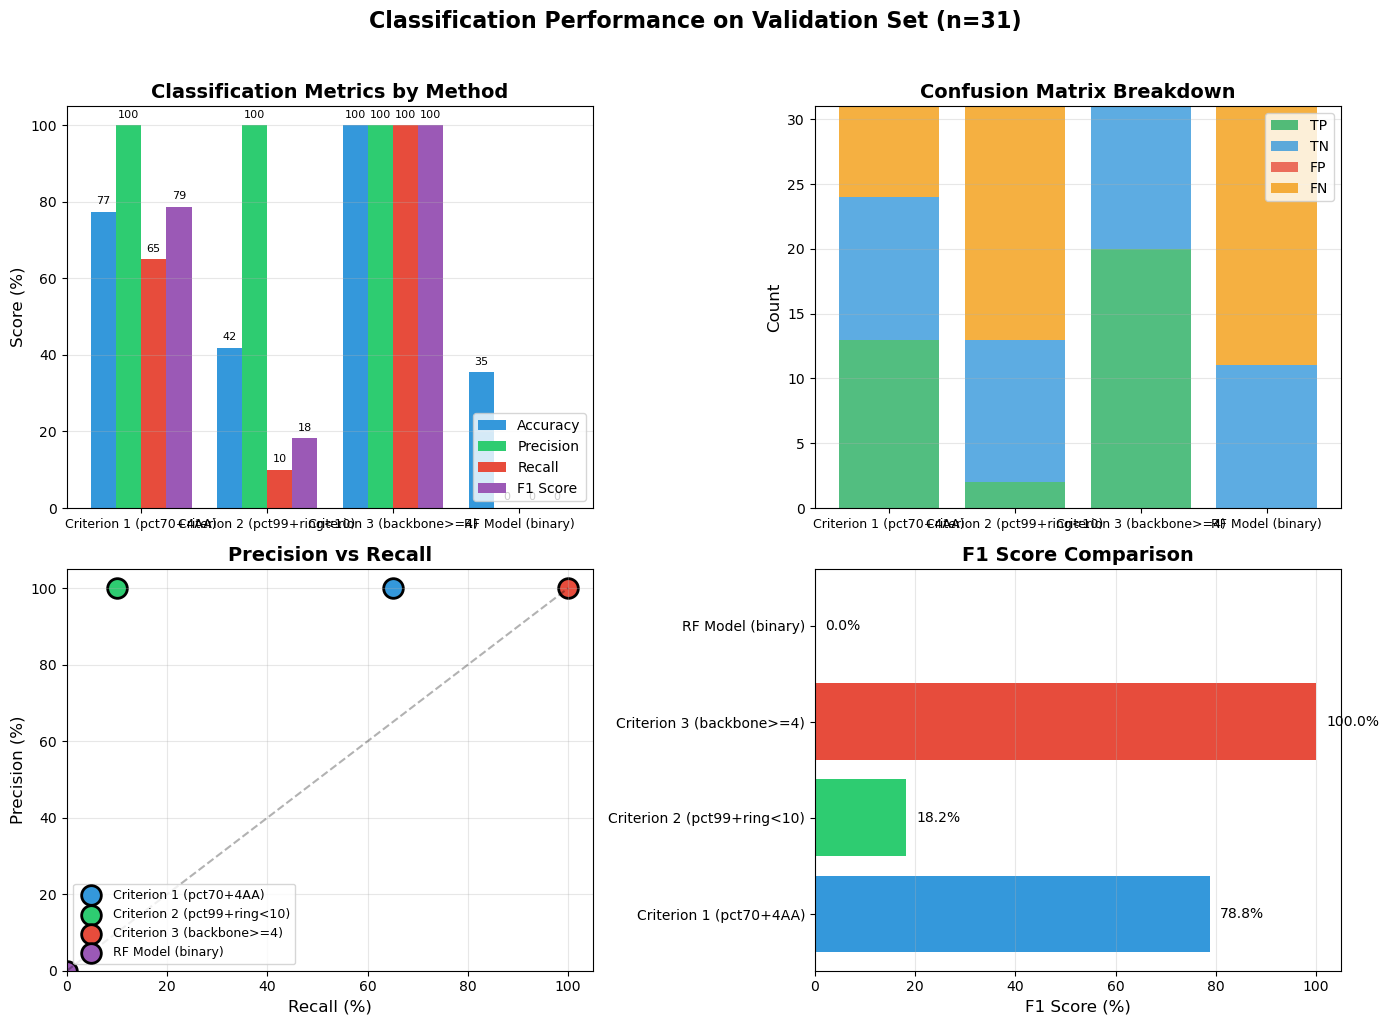


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/validation_classification_metrics.png

SUMMARY TABLE


,Protein name,Binder type,binder_standardized,pred_pct70_4aa,pred_pct99_ring10,pred_backbone4,pred_rf_binary,pct_peptide_content,total_aa_patterns,peptide_backbone_length
0,MC4R,Peptide,peptide,sm,sm,peptide,sm,32.051282,2.0,7.0
1,MC4R,Peptide,peptide,sm,sm,peptide,sm,32.116788,5.0,11.0
2,MC4R,Peptide,peptide,sm,sm,peptide,sm,44.000000,3.0,6.0
3,MC4R,Peptide,peptide,sm,sm,peptide,sm,40.740741,3.0,8.0
4,MC4R,Peptide,peptide,sm,sm,peptide,sm,50.666667,4.0,8.0
5,MC4R,Small molecule,sm,sm,sm,sm,sm,0.000000,0.0,0.0
6,MC4R,Small molecule,sm,sm,sm,sm,sm,0.000000,0.0,0.0
7,MC4R,Small molecule,sm,sm,sm,sm,sm,0.000000,0.0,1.0
10,GIPR,Peptide,peptide,peptide,sm,peptide,sm,85.590778,38.0,36.0
11,GIPR,Peptide,peptide,peptide,sm,peptide,sm,83.018868,37.0,37.0


In [27]:
# =============================================================================
# Standardize SMILES and Apply Classification Criteria
# =============================================================================

from rdkit import Chem
from rdkit.Chem import Descriptors

print("=" * 80)
print("Standardizing SMILES and Applying Classification Criteria")
print("=" * 80)

# Function to canonicalize SMILES
def canonicalize_smiles(smiles):
    """Convert SMILES to canonical form."""
    if pd.isna(smiles) or not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

# Canonicalize SMILES in peptides_sm_df
print("Canonicalizing SMILES...")
peptides_sm_df['SMILES_canonical'] = peptides_sm_df[smiles_col].apply(canonicalize_smiles)

n_original = len(peptides_sm_df)
n_valid = peptides_sm_df['SMILES_canonical'].notna().sum()
print(f"Original SMILES: {n_original}")
print(f"Valid canonical SMILES: {n_valid} ({n_valid/n_original*100:.1f}%)")

# Extract features for all SMILES
print("\nExtracting features...")

def extract_features_for_validation(smiles):
    """Extract features for a single SMILES."""
    if pd.isna(smiles):
        return {}
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
    try:
        feats = classifier.extract_features(mol)
        if isinstance(feats, dict):
            return feats
        feat_str = str(feats)
        return parse_feature_string(feat_str)
    except:
        return {}

# Extract features
features_list = []
for smiles in tqdm(peptides_sm_df['SMILES_canonical'], desc="Extracting features"):
    features_list.append(extract_features_for_validation(smiles))

features_validation = pd.DataFrame(features_list)
print(f"Extracted features for {len(features_validation)} molecules")
print(f"Feature columns: {len(features_validation.columns)}")

# Add features to peptides_sm_df
for col in features_validation.columns:
    peptides_sm_df[col] = features_validation[col].values

# Calculate peptide heavy atoms and pct_peptide_content
AA_HEAVY_ATOMS = {
    'pattern_AA_GLYCINE': 4, 'pattern_AA_ALANINE': 5, 'pattern_AA_SERINE': 6,
    'pattern_AA_CYSTEINE': 6, 'pattern_AA_THREONINE': 7, 'pattern_AA_PROLINE': 7,
    'pattern_AA_VALINE': 7, 'pattern_AA_LEUCINE': 8, 'pattern_AA_ISOLEUCINE': 8,
    'pattern_AA_ASPARAGINE': 8, 'pattern_AA_ASPARTATE': 8, 'pattern_AA_METHIONINE': 8,
    'pattern_AA_GLUTAMINE': 9, 'pattern_AA_GLUTAMATE': 9, 'pattern_AA_LYSINE': 9,
    'pattern_AA_HISTIDINE': 10, 'pattern_AA_PHENYLALANINE': 11, 'pattern_AA_TYROSINE': 12,
    'pattern_AA_TRYPTOPHAN': 14,
}

peptides_sm_df['peptide_heavy_atoms'] = 0
for aa_col, heavy in AA_HEAVY_ATOMS.items():
    if aa_col in peptides_sm_df.columns:
        peptides_sm_df['peptide_heavy_atoms'] += peptides_sm_df[aa_col].fillna(0).astype(int) * heavy

peptides_sm_df['pct_peptide_content'] = (
    peptides_sm_df['peptide_heavy_atoms'] / peptides_sm_df['heavy_atom_count'] * 100
).fillna(0)

# Count total AA patterns
AA_PATTERN_COLS = [col for col in AA_HEAVY_ATOMS.keys() if col in peptides_sm_df.columns]
peptides_sm_df['total_aa_patterns'] = peptides_sm_df[AA_PATTERN_COLS].fillna(0).sum(axis=1)

print("\nApplying classification criteria...")

# Get feature columns
pct = peptides_sm_df['pct_peptide_content'].fillna(0)
lrs = peptides_sm_df['largest_ring_size'].fillna(0) if 'largest_ring_size' in peptides_sm_df.columns else 0
pbl = peptides_sm_df['peptide_backbone_length'].fillna(0) if 'peptide_backbone_length' in peptides_sm_df.columns else 0
aa_count = peptides_sm_df['total_aa_patterns']

# CRITERION 1: >70% peptide content AND >=4 amino acid patterns
crit1 = (pct > 70) & (aa_count >= 4)
peptides_sm_df['pred_pct70_4aa'] = 'sm'
peptides_sm_df.loc[crit1, 'pred_pct70_4aa'] = 'peptide'

# CRITERION 2: >99% peptide content AND largest_ring_size < 10
crit2 = (pct > 99) & (lrs < 10)
peptides_sm_df['pred_pct99_ring10'] = 'sm'
peptides_sm_df.loc[crit2, 'pred_pct99_ring10'] = 'peptide'

# CRITERION 3: peptide_backbone_length >= 4
crit3 = pbl >= 4
peptides_sm_df['pred_backbone4'] = 'sm'
peptides_sm_df.loc[crit3, 'pred_backbone4'] = 'peptide'

# RF MODEL classification
print("Applying RF model...")
# Ensure all model features exist
for col in MODEL_FEATURE_COLUMNS:
    if col not in peptides_sm_df.columns:
        peptides_sm_df[col] = 0

X_val = peptides_sm_df[MODEL_FEATURE_COLUMNS].fillna(0).values
y_pred_val = rf_model.predict(X_val)
peptides_sm_df['pred_rf_model'] = label_encoder.inverse_transform(y_pred_val)
peptides_sm_df['pred_rf_binary'] = peptides_sm_df['pred_rf_model'].apply(
    lambda x: 'peptide' if x in ['can_pep', 'can_peptide', 'peptide'] else 'sm'
)

# Drop rows with NaN in key columns
print("\nDropping rows with NaN values...")
key_cols = ['binder_standardized', 'SMILES_canonical', 'pct_peptide_content']
valid_df = peptides_sm_df.dropna(subset=key_cols).copy()
print(f"Valid records: {len(valid_df)} of {len(peptides_sm_df)}")

print("\n" + "=" * 80)
print("CLASSIFICATION RESULTS vs GROUND TRUTH")
print("=" * 80)

# Compare each criterion and collect metrics
pred_cols = [
    ('pred_pct70_4aa', 'Criterion 1\n(pct70+4AA)'),
    ('pred_pct99_ring10', 'Criterion 2\n(pct99+ring<10)'),
    ('pred_backbone4', 'Criterion 3\n(backbone>=4)'),
    ('pred_rf_binary', 'RF Model\n(binary)')
]

metrics = {'method': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 
           'tp': [], 'tn': [], 'fp': [], 'fn': []}

for pred_col, name in pred_cols:
    print(f"\n--- {name.replace(chr(10), ' ')} ---")
    crosstab = pd.crosstab(valid_df['binder_standardized'], valid_df[pred_col], margins=True)
    print(crosstab)
    
    # Calculate metrics
    tp = ((valid_df['binder_standardized']=='peptide') & (valid_df[pred_col]=='peptide')).sum()
    tn = ((valid_df['binder_standardized']=='sm') & (valid_df[pred_col]=='sm')).sum()
    fp = ((valid_df['binder_standardized']=='sm') & (valid_df[pred_col]=='peptide')).sum()
    fn = ((valid_df['binder_standardized']=='peptide') & (valid_df[pred_col]=='sm')).sum()
    
    total = len(valid_df)
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nAccuracy: {accuracy*100:.1f}%")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
    
    metrics['method'].append(name)
    metrics['accuracy'].append(accuracy)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)
    metrics['f1'].append(f1)
    metrics['tp'].append(tp)
    metrics['tn'].append(tn)
    metrics['fp'].append(fp)
    metrics['fn'].append(fn)

metrics_df = pd.DataFrame(metrics)

# =============================================================================
# VISUALIZATION
# =============================================================================
print("\n" + "=" * 80)
print("VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy, Precision, Recall, F1 Bar Chart
ax1 = axes[0, 0]
x = np.arange(len(pred_cols))
width = 0.2
ax1.bar(x - 1.5*width, metrics_df['accuracy']*100, width, label='Accuracy', color='#3498db')
ax1.bar(x - 0.5*width, metrics_df['precision']*100, width, label='Precision', color='#2ecc71')
ax1.bar(x + 0.5*width, metrics_df['recall']*100, width, label='Recall', color='#e74c3c')
ax1.bar(x + 1.5*width, metrics_df['f1']*100, width, label='F1 Score', color='#9b59b6')
ax1.set_ylabel('Score (%)', fontsize=12)
ax1.set_title('Classification Metrics by Method', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace('\n', ' ') for m in metrics_df['method']], fontsize=9)
ax1.legend(loc='lower right')
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (acc, prec, rec, f1) in enumerate(zip(metrics_df['accuracy'], metrics_df['precision'], 
                                              metrics_df['recall'], metrics_df['f1'])):
    ax1.text(i - 1.5*width, acc*100 + 2, f'{acc*100:.0f}', ha='center', fontsize=8)
    ax1.text(i - 0.5*width, prec*100 + 2, f'{prec*100:.0f}', ha='center', fontsize=8)
    ax1.text(i + 0.5*width, rec*100 + 2, f'{rec*100:.0f}', ha='center', fontsize=8)
    ax1.text(i + 1.5*width, f1*100 + 2, f'{f1*100:.0f}', ha='center', fontsize=8)

# Plot 2: Confusion Matrix Heatmaps
ax2 = axes[0, 1]
# Stacked bar for TP, TN, FP, FN
bottom = np.zeros(4)
colors = ['#27ae60', '#3498db', '#e74c3c', '#f39c12']
labels = ['TP', 'TN', 'FP', 'FN']
for i, (col, color, label) in enumerate(zip(['tp', 'tn', 'fp', 'fn'], colors, labels)):
    ax2.bar(x, metrics_df[col], bottom=bottom, label=label, color=color, alpha=0.8)
    bottom += metrics_df[col].values
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Confusion Matrix Breakdown', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('\n', ' ') for m in metrics_df['method']], fontsize=9)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Precision vs Recall scatter
ax3 = axes[1, 0]
colors_scatter = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for i, (name, prec, rec) in enumerate(zip(metrics_df['method'], metrics_df['precision'], metrics_df['recall'])):
    ax3.scatter(rec*100, prec*100, s=200, c=colors_scatter[i], label=name.replace('\n', ' '), edgecolors='black', linewidth=2)
ax3.set_xlabel('Recall (%)', fontsize=12)
ax3.set_ylabel('Precision (%)', fontsize=12)
ax3.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
ax3.legend(loc='lower left', fontsize=9)
ax3.set_xlim(0, 105)
ax3.set_ylim(0, 105)
ax3.grid(True, alpha=0.3)
ax3.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='y=x')

# Plot 4: F1 Score comparison
ax4 = axes[1, 1]
bars = ax4.barh(metrics_df['method'].str.replace('\n', ' '), metrics_df['f1']*100, color=colors_scatter)
ax4.set_xlabel('F1 Score (%)', fontsize=12)
ax4.set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
ax4.set_xlim(0, 105)
ax4.grid(True, alpha=0.3, axis='x')
# Add value labels
for bar, f1 in zip(bars, metrics_df['f1']):
    ax4.text(f1*100 + 2, bar.get_y() + bar.get_height()/2, f'{f1*100:.1f}%', va='center', fontsize=10)

plt.suptitle(f'Classification Performance on Validation Set (n={len(valid_df)})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/validation_classification_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/validation_classification_metrics.png")

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
display(valid_df[['Protein name', binder_col, 'binder_standardized', 
                  'pred_pct70_4aa', 'pred_pct99_ring10', 'pred_backbone4', 'pred_rf_binary',
                  'pct_peptide_content', 'total_aa_patterns', 'peptide_backbone_length']].head(30))


CONFUSION MATRIX PLOTS


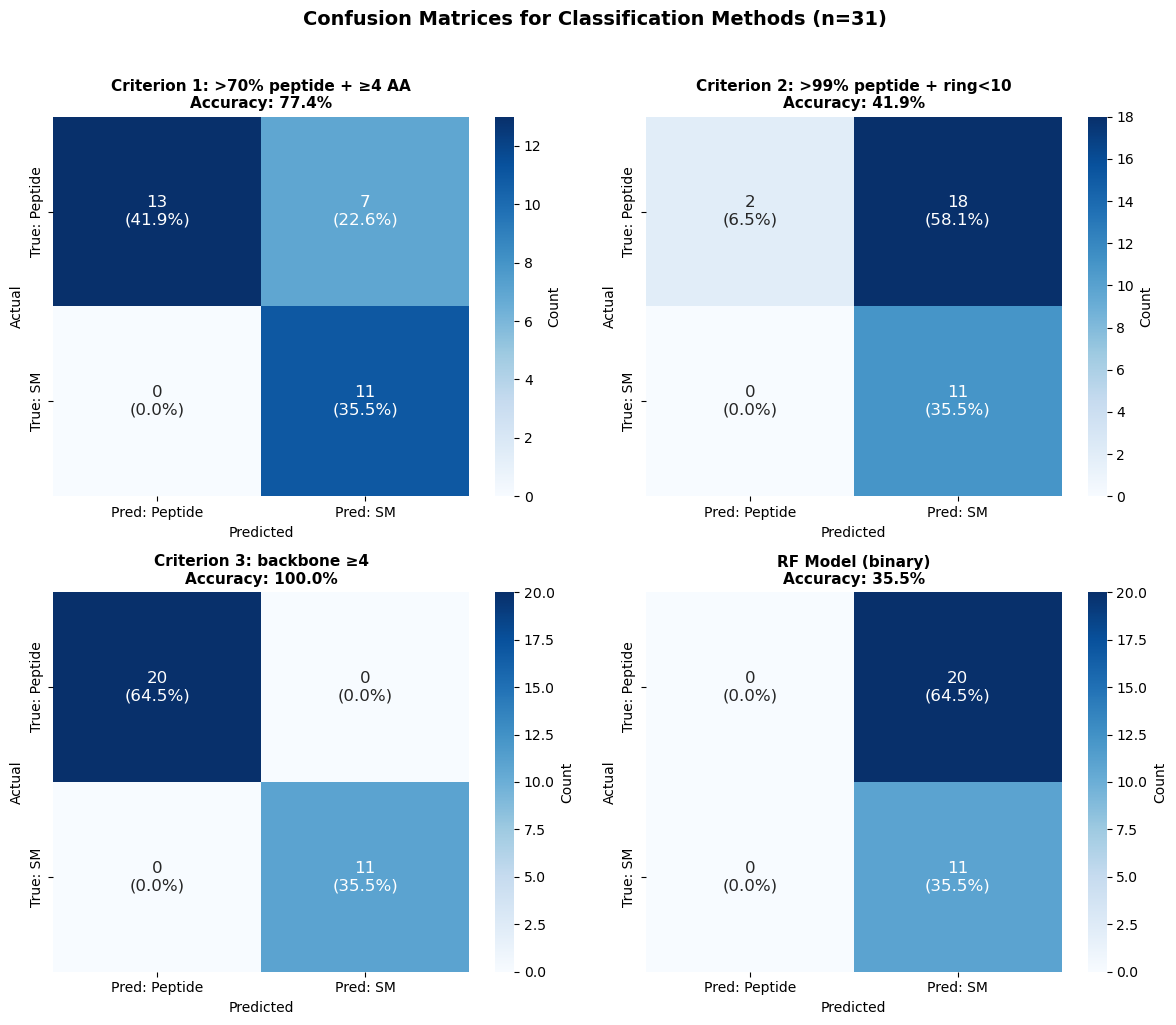


Saved plot to /fsx/amira/papyrus_50.5_results/features_only/validation_confusion_matrices.png


In [28]:
# =============================================================================
# CONFUSION MATRIX PLOTS
# =============================================================================
import seaborn as sns

print("=" * 80)
print("CONFUSION MATRIX PLOTS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pred_cols_cm = [
    ('pred_pct70_4aa', 'Criterion 1: >70% peptide + ≥4 AA'),
    ('pred_pct99_ring10', 'Criterion 2: >99% peptide + ring<10'),
    ('pred_backbone4', 'Criterion 3: backbone ≥4'),
    ('pred_rf_binary', 'RF Model (binary)')
]

for ax, (pred_col, title) in zip(axes.flatten(), pred_cols_cm):
    # Create confusion matrix
    cm = pd.crosstab(valid_df['binder_standardized'], valid_df[pred_col])
    
    # Ensure proper order (peptide, sm)
    labels = ['peptide', 'sm']
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    
    # Calculate percentages
    cm_pct = cm / cm.values.sum() * 100
    
    # Create annotation text with counts and percentages
    annot = []
    for i in range(len(labels)):
        row = []
        for j in range(len(labels)):
            count = cm.iloc[i, j]
            pct = cm_pct.iloc[i, j]
            row.append(f'{count}\n({pct:.1f}%)')
        annot.append(row)
    
    # Plot heatmap
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Pred: Peptide', 'Pred: SM'],
                yticklabels=['True: Peptide', 'True: SM'],
                cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12})
    
    # Calculate accuracy for title
    tp = cm.iloc[0, 0]  # peptide -> peptide
    tn = cm.iloc[1, 1]  # sm -> sm
    total = cm.values.sum()
    acc = (tp + tn) / total * 100 if total > 0 else 0
    
    ax.set_title(f'{title}\nAccuracy: {acc:.1f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle(f'Confusion Matrices for Classification Methods (n={len(valid_df)})', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/validation_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/validation_confusion_matrices.png")


In [35]:
# =============================================================================
# STEP 6a: Save Top 50 and Top 100 Targets Data for Each Criteria
# =============================================================================

print("=" * 80)
print("STEP 6a: Saving Top 50 & Top 100 Targets Data per Criteria")
print("=" * 80)

class_cols = ['class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
class_names = ['pct70_4aa', 'pct99_ring10', 'backbone4', 'rf_binary']

for col, name in zip(class_cols, class_names):
    print(f"\n--- Processing: {col} ---")
    
    # Get target stats and sort by peptide count
    target_stats = papyrus_df.groupby('accession')[col].value_counts().unstack(fill_value=0)
    if 'peptide' not in target_stats.columns:
        target_stats['peptide'] = 0
    if 'sm' not in target_stats.columns:
        target_stats['sm'] = 0
    target_stats = target_stats.sort_values('peptide', ascending=False)
    
    # Save for both top 50 and top 100
    for top_n in [50, 20]:
        top_accessions = target_stats.head(top_n).index.tolist()
        
        # Filter papyrus_df to only include these targets
        filtered_df = papyrus_df[papyrus_df['accession'].isin(top_accessions)].copy()
        
        # Count peptides and SM in filtered data
        n_peptides = (filtered_df[col] == 'peptide').sum()
        n_sm = (filtered_df[col] == 'sm').sum()
        print(f"\n  Top {top_n} targets: {len(filtered_df):,} records ({n_peptides:,} peptides, {n_sm:,} SM)")
        
        # Save to CSV (gzip compressed)
        output_file = f"{OUTPUT_DIR}/top{top_n}_targets_data_{name}.csv.gz"
        filtered_df.to_csv(output_file, index=False, compression='gzip')
        print(f"    Saved to: {output_file}")
        


print("\n" + "=" * 80)
print("All top 50 & top 100 target datasets saved!")
print("=" * 80)


STEP 6a: Saving Top 50 & Top 100 Targets Data per Criteria

--- Processing: class_pct70_4aa ---

  Top 50 targets: 4,717,608 records (5,033 peptides, 4,712,575 SM)
    Saved to: /fsx/amira/papyrus_50.5_results/features_only/top50_targets_data_pct70_4aa.csv.gz

  Top 20 targets: 3,002,618 records (3,376 peptides, 2,999,242 SM)
    Saved to: /fsx/amira/papyrus_50.5_results/features_only/top20_targets_data_pct70_4aa.csv.gz

--- Processing: class_pct99_ring10 ---

  Top 50 targets: 14,480,459 records (2,254 peptides, 14,478,205 SM)
    Saved to: /fsx/amira/papyrus_50.5_results/features_only/top50_targets_data_pct99_ring10.csv.gz

  Top 20 targets: 4,428,789 records (1,485 peptides, 4,427,304 SM)
    Saved to: /fsx/amira/papyrus_50.5_results/features_only/top20_targets_data_pct99_ring10.csv.gz

--- Processing: class_backbone4 ---

  Top 50 targets: 4,085,510 records (8,094 peptides, 4,077,416 SM)
    Saved to: /fsx/amira/papyrus_50.5_results/features_only/top50_targets_data_backbone4.csv.gz

In [36]:
# =============================================================================
# STEP 6: Save Final Dataset
# =============================================================================

print("=" * 80)
print("STEP 6: Saving final dataset")
print("=" * 80)

# Save full dataset with gzip compression (faster than xz)
output_file = f"{OUTPUT_DIR}/papyrus_with_features_and_classifications.csv.gz"
print(f"\nSaving {len(papyrus_df):,} records to: {output_file}")
papyrus_df.to_csv(output_file, index=False, compression='gzip')
print(f"Saved: {output_file}")

# Also save a smaller summary with unique SMILES and their classifications
print("\nSaving unique SMILES summary...")
unique_cols = ['SMILES', 'molecular_weight', 'heavy_atom_count', 'peptide_backbone_length', 
               'peptide_bond_count', 'pct_peptide_content', 'largest_ring_size',
               'class_pct70_4aa', 'class_pct99_ring10', 'class_backbone4', 'class_rf_binary']
unique_cols = [c for c in unique_cols if c in papyrus_df.columns]
unique_smiles_df = papyrus_df.drop_duplicates(subset='SMILES')[unique_cols]
unique_file = f"{OUTPUT_DIR}/unique_smiles_classifications.csv"
unique_smiles_df.to_csv(unique_file, index=False)
print(f"Saved {len(unique_smiles_df):,} unique SMILES to: {unique_file}")

print(f"\nDone!")
print(f"Final shape: {papyrus_df.shape}")
print(f"\n=== FILES SAVED ===")
print(f"1. Full dataset: {output_file}")
print(f"2. Unique SMILES: {unique_file}")
print(f"3. Target rankings: {OUTPUT_DIR}/top_targets_*.csv")
print(f"4. Priority overlaps: {OUTPUT_DIR}/priority_targets_overlap_*.csv")

print(f"\n" + "=" * 80)
print("SAVED FILES SUMMARY")
print("=" * 80)

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"\nData file:")
print(f"  {output_file}")


print(f"\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\nTotal records: {n_total:,}")
print(f"Unique SMILES: {n_unique_smiles:,}")
print(f"Unique targets: {n_unique_targets:,}")
print(f"\nClassification results:")
print(f"  - class_pct70_4aa:     {n_pep1_full:,} peptides ({n_pep1_full/n_total*100:.3f}%)")
print(f"  - class_pct99_ring10:  {n_pep2_full:,} peptides ({n_pep2_full/n_total*100:.3f}%)")
print(f"  - class_backbone4:     {n_pep3_full:,} peptides ({n_pep3_full/n_total*100:.3f}%)")
print(f"  - class_rf_binary:     {n_rf_pep_full:,} peptides ({n_rf_pep_full/n_total*100:.3f}%)")

print(f"\n" + "=" * 80)
print("COMPLETE!")
print("=" * 80)


STEP 6: Saving final dataset

Saving 59,775,087 records to: /fsx/amira/papyrus_50.5_results/features_only/papyrus_with_features_and_classifications.csv.gz
Saved: /fsx/amira/papyrus_50.5_results/features_only/papyrus_with_features_and_classifications.csv.gz

Saving unique SMILES summary...
Saved 1,424,987 unique SMILES to: /fsx/amira/papyrus_50.5_results/features_only/unique_smiles_classifications.csv

Done!
Final shape: (59775087, 11)

=== FILES SAVED ===
1. Full dataset: /fsx/amira/papyrus_50.5_results/features_only/papyrus_with_features_and_classifications.csv.gz
2. Unique SMILES: /fsx/amira/papyrus_50.5_results/features_only/unique_smiles_classifications.csv
3. Target rankings: /fsx/amira/papyrus_50.5_results/features_only/top_targets_*.csv
4. Priority overlaps: /fsx/amira/papyrus_50.5_results/features_only/priority_targets_overlap_*.csv

SAVED FILES SUMMARY

Output directory: /fsx/amira/papyrus_50.5_results/features_only

Data file:
  /fsx/amira/papyrus_50.5_results/features_only/p